# Paquetes

In [1]:
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, roc_curve
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import pickle

from tensorflow.keras.regularizers import l2
from sklearn.model_selection import KFold
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, EarlyStopping
import numpy as np

import pennylane as qml
from pennylane import numpy as np

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.optimizers import Adam
import os
from PIL import Image
from multiprocessing import Pool
import pickle

import matplotlib.pyplot as plt
import matplotlib.lines as mlines

import pandas as pd

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

from collections import defaultdict

import re

import random

In [2]:
random_seed=42


# Carga de Datos

### Recuento inicial

In [3]:
base_dirs = ["ACDC", "LaFe"]
categories = ["C", "MCD", "MCA", "MU"]

counts = {base: defaultdict(int) for base in base_dirs}
total_counts = defaultdict(int)

for base_dir in base_dirs:
    for subfolder in categories:
        path = "dataset/" + base_dir + "/" + subfolder
        if os.path.exists(path):
            patients = {f for f in os.listdir(path) if f.endswith(".nii.gz")}
            counts[base_dir][subfolder] = len(patients)
            total_counts[subfolder] += len(patients)

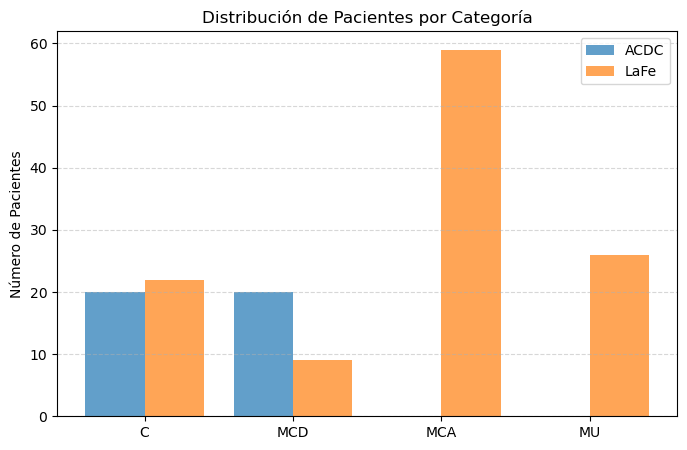

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
x = range(len(categories))

width = 0.4
ax.bar(x, [counts["ACDC"][cat] for cat in categories], width=width, label="ACDC", alpha=0.7)
ax.bar([i + width for i in x], [counts["LaFe"][cat] for cat in categories], width=width, label="LaFe", alpha=0.7)

ax.set_xticks([i + width / 2 for i in x])
ax.set_xticklabels(categories)
ax.set_ylabel("Número de Pacientes")
ax.set_title("Distribución de Pacientes por Categoría")
ax.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

In [5]:
df_count = pd.DataFrame(counts).T 
df_count = pd.DataFrame(counts).T.fillna(0).astype(int)
df_count["Total"] = df_count.sum(axis=1)
df_count.loc["Total"] = df_count.sum(axis=0)

df_count

,C,MCD,MCA,MU,Total
ACDC,20,20,0,0,40
LaFe,22,9,59,26,116
Total,42,29,59,26,156


### Muestreo uniforme

Priorizamos los pacientes de La Fe, usando los del challenge en caso de ausencia de datos

In [4]:
base_dir = "LaFe"
num_samples = 35

random.seed(random_seed)

data = {category: [] for category in categories}

for subfolder in categories:
    path = "dataset/" + base_dir + "/" + subfolder
    if os.path.exists(path):
        patients = {f for f in os.listdir(path) if f.endswith(".nii.gz")}
        sampled_patients = random.sample(patients, min(num_samples, len(patients)))
        data[subfolder].extend([base_dir+"/"+subfolder+"/"+patient.replace(".nii.gz", "") for patient in sampled_patients])

base_dir = "ACDC"
for subfolder in categories:
    path = "dataset/" + base_dir + "/" + subfolder
    if os.path.exists(path):
        patients = {f for f in os.listdir(path) if f.endswith(".nii.gz")}
        sampled_patients = random.sample(patients, min(num_samples-len(data[subfolder]), len(patients)))
        data[subfolder].extend([base_dir+"/"+subfolder+"/"+patient.replace(".nii.gz", "") for patient in sampled_patients])

C:\Users\mateo\AppData\Local\Temp\ipykernel_23476\274377643.py:12: DeprecationWarning: Sampling from a set deprecated
since Python 3.9 and will be removed in a subsequent version.
  sampled_patients = random.sample(patients, min(num_samples, len(patients)))
C:\Users\mateo\AppData\Local\Temp\ipykernel_23476\274377643.py:20: DeprecationWarning: Sampling from a set deprecated
since Python 3.9 and will be removed in a subsequent version.
  sampled_patients = random.sample(patients, min(num_samples-len(data[subfolder]), len(patients)))


In [5]:
all_data = [(p, cat) for cat, patients in data.items() for p in patients]

df = pd.DataFrame(all_data, columns=["patient", "category"])

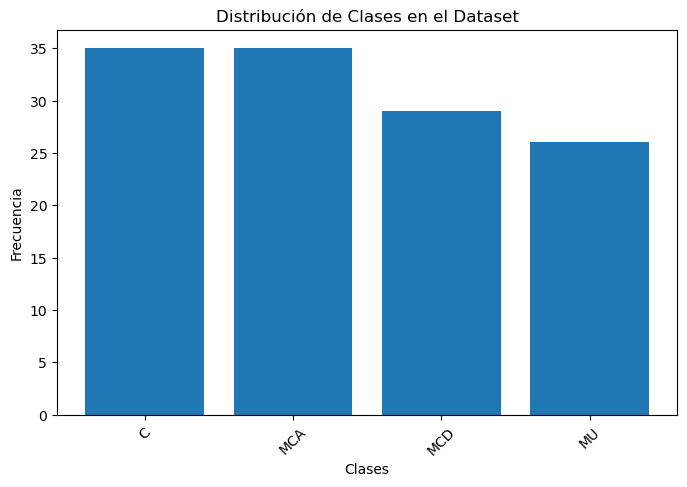

In [6]:
class_counts = df["category"].value_counts()

# Graficar el histograma
plt.figure(figsize=(8, 5))
plt.bar(class_counts.index, class_counts.values)

# Personalizar el gráfico
plt.xlabel("Clases")
plt.ylabel("Frecuencia")
plt.title("Distribución de Clases en el Dataset")
plt.xticks(rotation=45)

# Mostrar el histograma
plt.show()

## Partición

In [ ]:
train, temp = train_test_split(df, test_size=0.3, stratify=df["category"], random_state=42)
val, test = train_test_split(temp, test_size=1/3, stratify=temp["category"], random_state=42)

In [8]:
train

,patient,category
27,ACDC/C/patient062_4d_ES9,C
16,LaFe/C/C_10,C
109,LaFe/MU/9066,MU
100,LaFe/MU/MU_05,MU
57,ACDC/MCD/patient008_4d_ES13,MCD
...,...,...
24,ACDC/C/patient077_4d_ES9,C
113,LaFe/MU/9065,MU
65,LaFe/MCA/9108,MCA
47,ACDC/MCD/patient003_4d_ES15,MCD


# Crear datos (NO EJECUTAR)

## Train

In [3]:
extract_dir = "results/imagenes"

array_shape = (64, 64)

In [11]:
image_labels_tr = []
image_tr=[]

for _, row in train.iterrows():
    folder_path = row["patient"]
    category = row["category"]
    patient_name = os.path.basename(folder_path).split("/")[-1]
    path = extract_dir+"/"+folder_path
    for type in os.listdir(path):
        path = extract_dir+"/"+folder_path+"/"+type
        for img_path in os.listdir(path):
            path = extract_dir+"/"+folder_path+"/"+type+"/"+img_path
            img = Image.open(path)
            img = img.convert('RGB')
            img = img.resize(array_shape)
            img_array = np.array(img)

            img_number = re.search(r"_(\d{2})_", img_path).group(1)

            image_labels_tr.append({
                "patient_name": patient_name,
                "class": category,
                "image_type": type,
                "img_number": img_number,
            })

            image_tr.append(img_array)

image_tr = np.array(image_tr)

train_imgs_tf = (image_tr / 255)*np.pi
df_tr = pd.DataFrame(image_labels_tr)

print(df_tr.head(10))
print(df_tr.shape)

print(train_imgs_tf.shape)

with open("data_pi/train_imgs_tf1.pkl", "wb") as file:
    pickle.dump(train_imgs_tf, file)

with open("data_pi/df_tr1.pkl", "wb") as file:
    pickle.dump(df_tr, file)

        patient_name class       image_type img_number
0  patient062_4d_ES9     C  circunferencial         00
1  patient062_4d_ES9     C  circunferencial         01
2  patient062_4d_ES9     C  circunferencial         02
3  patient062_4d_ES9     C  circunferencial         03
4  patient062_4d_ES9     C  circunferencial         04
5  patient062_4d_ES9     C  circunferencial         05
6  patient062_4d_ES9     C  circunferencial         06
7  patient062_4d_ES9     C  circunferencial         07
8  patient062_4d_ES9     C  circunferencial         08
9  patient062_4d_ES9     C  circunferencial         09
(2784, 4)
(2784, 64, 64, 3)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


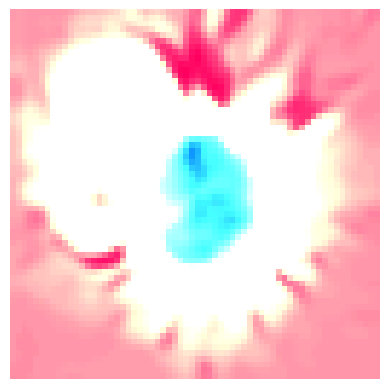

In [16]:
plt.imshow(train_imgs_tf[0,:,:])
plt.axis('off')
plt.show()

## Validation

In [17]:
image_labels_val = []
image_val=[]

for _, row in val.iterrows():
    folder_path = row["patient"]
    category = row["category"]
    patient_name = os.path.basename(folder_path).split("/")[-1]
    path = extract_dir+"/"+folder_path
    for type in os.listdir(path):
        path = extract_dir+"/"+folder_path+"/"+type
        for img_path in os.listdir(path):
            path = extract_dir+"/"+folder_path+"/"+type+"/"+img_path
            with Image.open(path) as img:
                img = img.convert('RGB')
                img = img.resize(array_shape)
                img_array = np.array(img)

            img_number = re.search(r"_(\d{2})_", img_path).group(1)

            image_labels_val.append({
                "patient_name": patient_name,
                "class": category,
                "image_type": type,
                "img_number": img_number,
            })

            image_val.append(img_array)

image_val = np.array(image_val)

val_imgs_tf = (image_val / 255)*np.pi
df_val = pd.DataFrame(image_labels_val)

print(df_val.head(10))
print(df_val.shape)

print(val_imgs_tf.shape)

with open("data_pi/val_imgs_tf1.pkl", "wb") as file:
    pickle.dump(val_imgs_tf, file)

with open("data_pi/df_val1.pkl", "wb") as file:
    pickle.dump(df_val, file)

        patient_name class       image_type img_number
0  patient075_4d_ES6     C  circunferencial         00
1  patient075_4d_ES6     C  circunferencial         01
2  patient075_4d_ES6     C  circunferencial         02
3  patient075_4d_ES6     C  circunferencial         03
4  patient075_4d_ES6     C  circunferencial         04
5  patient075_4d_ES6     C  circunferencial         05
6  patient075_4d_ES6     C  circunferencial         06
7  patient075_4d_ES6     C  circunferencial         07
8  patient075_4d_ES6     C  circunferencial         08
9  patient075_4d_ES6     C  circunferencial         09
(800, 4)
(800, 64, 64, 3)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


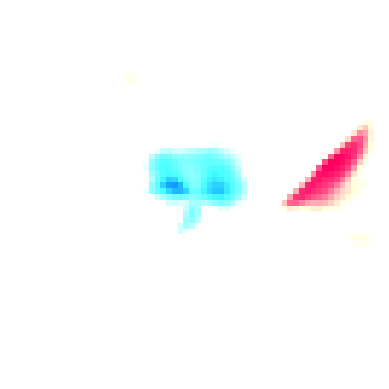

In [18]:
plt.imshow(val_imgs_tf[0,:,:])
plt.axis('off')
plt.show()

## Test

In [19]:
image_labels_test = []
image_test=[]

for _, row in test.iterrows():
    folder_path = row["patient"]
    category = row["category"]
    patient_name = os.path.basename(folder_path).split("/")[-1]
    path = extract_dir+"/"+folder_path
    for type in os.listdir(path):
        path = extract_dir+"/"+folder_path+"/"+type
        for img_path in os.listdir(path):
            path = extract_dir+"/"+folder_path+"/"+type+"/"+img_path
            with Image.open(path) as img:
                img = img.convert('RGB')
                img = img.resize(array_shape)
                img_array = np.array(img)

            img_number = re.search(r"_(\d{2})_", img_path).group(1)

            image_labels_test.append({
                "patient_name": patient_name,
                "class": category,
                "image_type": type,
                "img_number": img_number,
            })

            image_test.append(img_array)

image_test = np.array(image_test)

test_imgs_tf = (image_test / 255) *np.pi
df_test = pd.DataFrame(image_labels_test)

print(df_test.head(10))
print(df_test.shape)

print(test_imgs_tf.shape)

with open("data_pi/test_imgs_tf1.pkl", "wb") as file:
    pickle.dump(test_imgs_tf, file)

with open("data_pi/df_test1.pkl", "wb") as file:
    pickle.dump(df_test, file)

         patient_name class       image_type img_number
0  patient020_4d_ES11   MCD  circunferencial         00
1  patient020_4d_ES11   MCD  circunferencial         01
2  patient020_4d_ES11   MCD  circunferencial         02
3  patient020_4d_ES11   MCD  circunferencial         03
4  patient020_4d_ES11   MCD  circunferencial         04
5  patient020_4d_ES11   MCD  circunferencial         05
6  patient020_4d_ES11   MCD  circunferencial         06
7  patient020_4d_ES11   MCD  circunferencial         07
8  patient020_4d_ES11   MCD  circunferencial         08
9  patient020_4d_ES11   MCD  circunferencial         09
(416, 4)
(416, 64, 64, 3)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


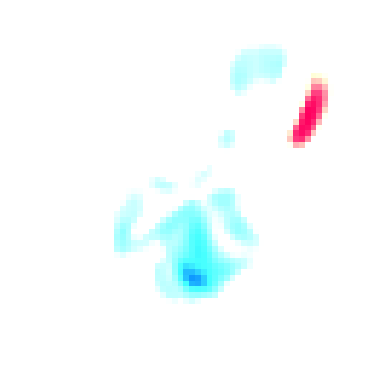

In [20]:
plt.imshow(test_imgs_tf[0,:,:])
plt.axis('off')
plt.show()

## Estadísticas de los datos

In [52]:
def plot_class_distribution(labels, dataset_name):
    unique_classes, counts = np.unique(labels, return_counts=True)
    plt.bar(unique_classes, counts)
    plt.title(f'Class Distribution in {dataset_name} Set')
    plt.xlabel('Class')
    plt.ylabel('Count')
    plt.show()


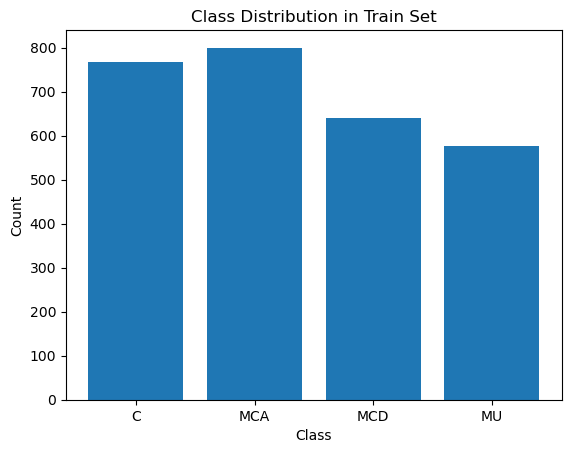

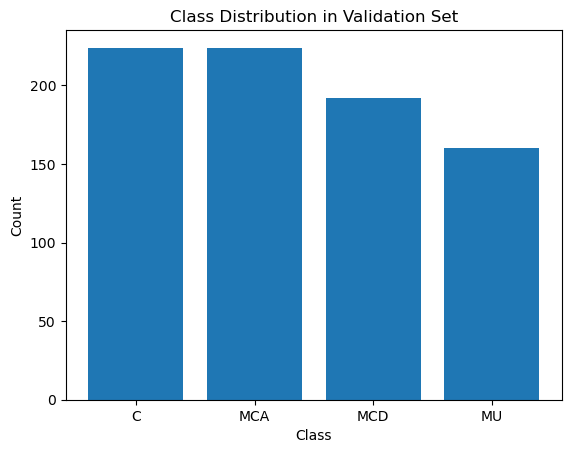

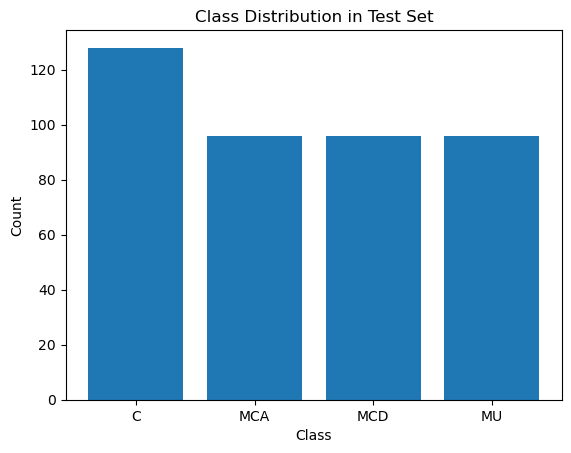

In [53]:
plot_class_distribution(df_tr["class"], 'Train')
plot_class_distribution(df_val["class"], 'Validation')
plot_class_distribution(df_test["class"], 'Test')

# Carga de datos

In [3]:
with open("data/nopi/train_imgs_tf.pkl", "rb") as f:
    train_imgs_tf = pickle.load(f)
with open("data/nopi/df_tr.pkl", "rb") as f:
    df_tr = pickle.load(f)

df_tr_rad = df_tr[df_tr["image_type"] == "radial"]
df_tr_circ = df_tr[df_tr["image_type"] == "circunferencial"]

train_imgs_tf_rad = train_imgs_tf[df_tr_rad.index]
train_imgs_tf_circ = train_imgs_tf[df_tr_circ.index]

with open("data/nopi/val_imgs_tf.pkl", "rb") as f:
    val_imgs_tf = pickle.load(f)
with open("data/nopi/df_val.pkl", "rb") as f:
    df_val = pickle.load(f)   

df_val_rad = df_val[df_val["image_type"] == "radial"]
df_val_circ = df_val[df_val["image_type"] == "circunferencial"]

val_imgs_tf_rad = val_imgs_tf[df_val_rad.index]
val_imgs_tf_circ = val_imgs_tf[df_val_circ.index]

with open("data/nopi/test_imgs_tf.pkl", "rb") as f:
    test_imgs_tf = pickle.load(f)
with open("data/nopi/df_test.pkl", "rb") as f:
    df_test = pickle.load(f)

df_test_rad = df_test[df_test["image_type"] == "radial"]
df_test_circ = df_test[df_test["image_type"] == "circunferencial"]

test_imgs_tf_rad = test_imgs_tf[df_test_rad.index]
test_imgs_tf_circ = test_imgs_tf[df_test_circ.index]

In [4]:
imgs_tf_rad = np.concatenate([train_imgs_tf_rad, val_imgs_tf_rad])
imgs_tf_circ = np.concatenate([train_imgs_tf_circ, val_imgs_tf_circ])

df_rad = pd.concat([df_tr_rad, df_val_rad], ignore_index=True)
df_circ = pd.concat([df_tr_circ, df_val_circ], ignore_index=True)

# Circuitos Cuánticos

In [10]:
n_qubits = 12
graphs = {
    "closed-nn" : [[0,6], [6,9], [9,3], [3,0], [0,1], [6,7], [9,10], [3,4], [1,7], [7,10], [10,4], [4,1], [1,2], [7,8], [10,11], [4,5], [2,8], [8,11], [11,5], [5,2]],
    "open-nn": [[0,1],[1,2],[2,8],[8,7],[7,6],[6,9],[9,10],[10,11],[11,5],[5,4],[4,3]]
}

dev = qml.device('default.qubit', wires=n_qubits)

## Closed

In [11]:
@qml.qnode(dev, interface="autograd")
def closed_circuit(params):
    """creates a quantum kernel based on a digital-analog quantum encoding.

    Args:
        params (torch.Parameters): trainable parameters

    Returns:
        list: expectation values of <Z> on each qubit
    """
    
    # DIGITAL ENCODING OF THE PIXELS
    for idx in range(n_qubits):
        qml.RY(params[idx], wires=idx)
        qml.Hadamard(wires=idx)
        
    # RYDBERG HAMILTONIAN EVOLUTION
    for t in [0.05, 0.1]:
        for qubit in range(n_qubits):
            qml.RX(t, wires=qubit)
            qml.RZ(t/2, wires=qubit)
        for pair in graphs["closed-nn"]:
            qml.CNOT(wires=[pair[0], pair[1]])
            qml.RZ(phi=np.pi/3, wires=pair[1])
            qml.CNOT(wires=[pair[0], pair[1]])
    
    # DIGITAL SINGLE-QUBIT OPERATIONS
    for qubit in range(n_qubits):
        qml.RY(np.pi/2, wires=qubit) 
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

## Opened

In [12]:
@qml.qnode(dev, interface="autograd")
def open_circuit(params):
    """creates a quantum kernel based on a digital-analog quantum encoding.

    Args:
        params (torch.Parameters): trainable parameters

    Returns:
        list: expectation values of <Z> on each qubit
    """
    
    # DIGITAL ENCODING OF THE PIXELS
    for idx in range(n_qubits):
        qml.RY(params[idx], wires=idx)
        qml.Hadamard(wires=idx)
        
    # RYDBERG HAMILTONIAN EVOLUTION
    for t in [0.05, 0.1]:
        for qubit in range(n_qubits):
            qml.RX(t, wires=qubit)
            qml.RZ(t/2, wires=qubit)
        for pair in graphs["open-nn"]:
            qml.CNOT(wires=[pair[0], pair[1]])
            qml.RZ(phi=np.pi/3, wires=pair[1])
            qml.CNOT(wires=[pair[0], pair[1]])
    
    # DIGITAL SINGLE-QUBIT OPERATIONS
    for qubit in range(n_qubits):
        qml.RY(np.pi/2, wires=qubit) 
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

# Quanvolución

In [13]:
def quanv(idx, image, folder):
    """Convolves the input image with many applications of the same quantum circuit."""
    out = np.zeros((array_shape[0]-1, array_shape[1]-1, 24))

    # Loop over the coordinates of the top-left pixel of 2X2 squares
    for j in range(0, array_shape[0]-1, 1):
        for k in range(0, array_shape[1]-1, 1):
            a0=image[j, k, 0]
            a1=image[j, k, 1]
            a2=image[j, k, 2]
            
            b0=image[j, k + 1, 0]
            b1=image[j, k + 1, 1]
            b2=image[j, k + 1, 2]
            
            c0=image[j + 1, k, 0]
            c1=image[j + 1, k, 1]
            c2=image[j + 1, k, 2]
            
            d0=image[j + 1, k + 1, 0]
            d1=image[j + 1, k + 1, 1]
            d2=image[j + 1, k + 1, 2]

            q1_results = closed_circuit( # circuit 2
                [
                    a0,
                    a1,
                    a2,
                    b0,
                    b1,
                    b2,
                    c0,
                    c1,
                    c2,
                    d0,
                    d1,
                    d2
                ]
            )
            q2_results = open_circuit( # circuit 3
                [
                    a0,
                    a1,
                    a2,
                    b0,
                    b1,
                    b2,
                    c0,
                    c1,
                    c2,
                    d0,
                    d1,
                    d2
                ]
            )

            for c in range(12):
                out[j, k, c] = q1_results[c]
            for c in range(12): 
                out[j, k, c+12] = q2_results[c]

    if folder=="train":
        with open(f"quantum/train/train_{idx}.pkl", "wb") as file:
            pickle.dump(out, file)
    elif folder=="validation":
        with open(f"quantum/validation/val_{idx}.pkl", "wb") as file:
            pickle.dump(out, file)
    elif folder=="test":
        with open(f"quantum/test/test_{idx}.pkl", "wb") as file:
            pickle.dump(out, file)

In [ ]:
if __name__=="__main__":
    num_cores = os.cpu_count() - 1
    
    pool_tr = Pool(processes=num_cores)
    pool_val = Pool(processes=num_cores)
    pool_test = Pool(processes=num_cores)
    
    # PROCCESS TRAIN DATA SET
    print("Quantum pre-processing of train images")
    for idx, img in enumerate(train_imgs_tf):
        pool_tr.apply_async(quanv, args=(idx,img,"train"))
    pool_tr.close()
    pool_tr.join()

    # PROCCESS VALIDATION DATA SET
    print("Quantum pre-processing of validation images")
    for idx, img in enumerate(val_imgs_tf):
        pool_val.apply_async(quanv, args=(idx,img,"validation"))
    pool_val.close()
    pool_val.join()
    
    # PROCCESS TEST DATA SET
    print("Quantum pre-processing of test images")
    for idx, img in enumerate(test_imgs_tf):
        pool_test.apply_async(quanv, args=(idx,img,"test"))
    pool_test.close()
    pool_test.join()

In [5]:
def load_data_to_cpu(file_pattern, num_files):
    data_list = []
    for idx in range(num_files):
        with open(file_pattern.format(idx), "rb") as file:
            data = pickle.load(file)
        data_list.append(data)
    data_array = np.asarray(data_list)
    return data_array

In [6]:
def cpu_to_gpu(X):
    X_tensor = tf.convert_to_tensor(X)
    
    return tf.identity(X_tensor)

In [7]:
q_train_images = load_data_to_cpu("quantum/nopi/train/train_{}.pkl", len(train_imgs_tf))
q_train_images_circ = q_train_images[df_tr_circ.index]
q_train_images_rad = q_train_images[df_tr_rad.index]
print(q_train_images.shape)

q_val_images = load_data_to_cpu("quantum/nopi/validation/val_{}.pkl", len(val_imgs_tf))
q_val_images_circ = q_val_images[df_val_circ.index]
q_val_images_rad = q_val_images[df_val_rad.index]
print(q_val_images.shape)

q_test_images = load_data_to_cpu("quantum/nopi/test/test_{}.pkl", len(test_imgs_tf))
q_test_images_circ = q_test_images[df_test_circ.index]
q_test_images_rad = q_test_images[df_test_rad.index]
print(q_test_images.shape)

q_images_rad = np.concatenate([q_train_images_rad, q_val_images_rad])
q_images_circ = np.concatenate([q_val_images_circ, q_train_images_circ])

(2784, 63, 63, 24)
(800, 63, 63, 24)
(416, 63, 63, 24)


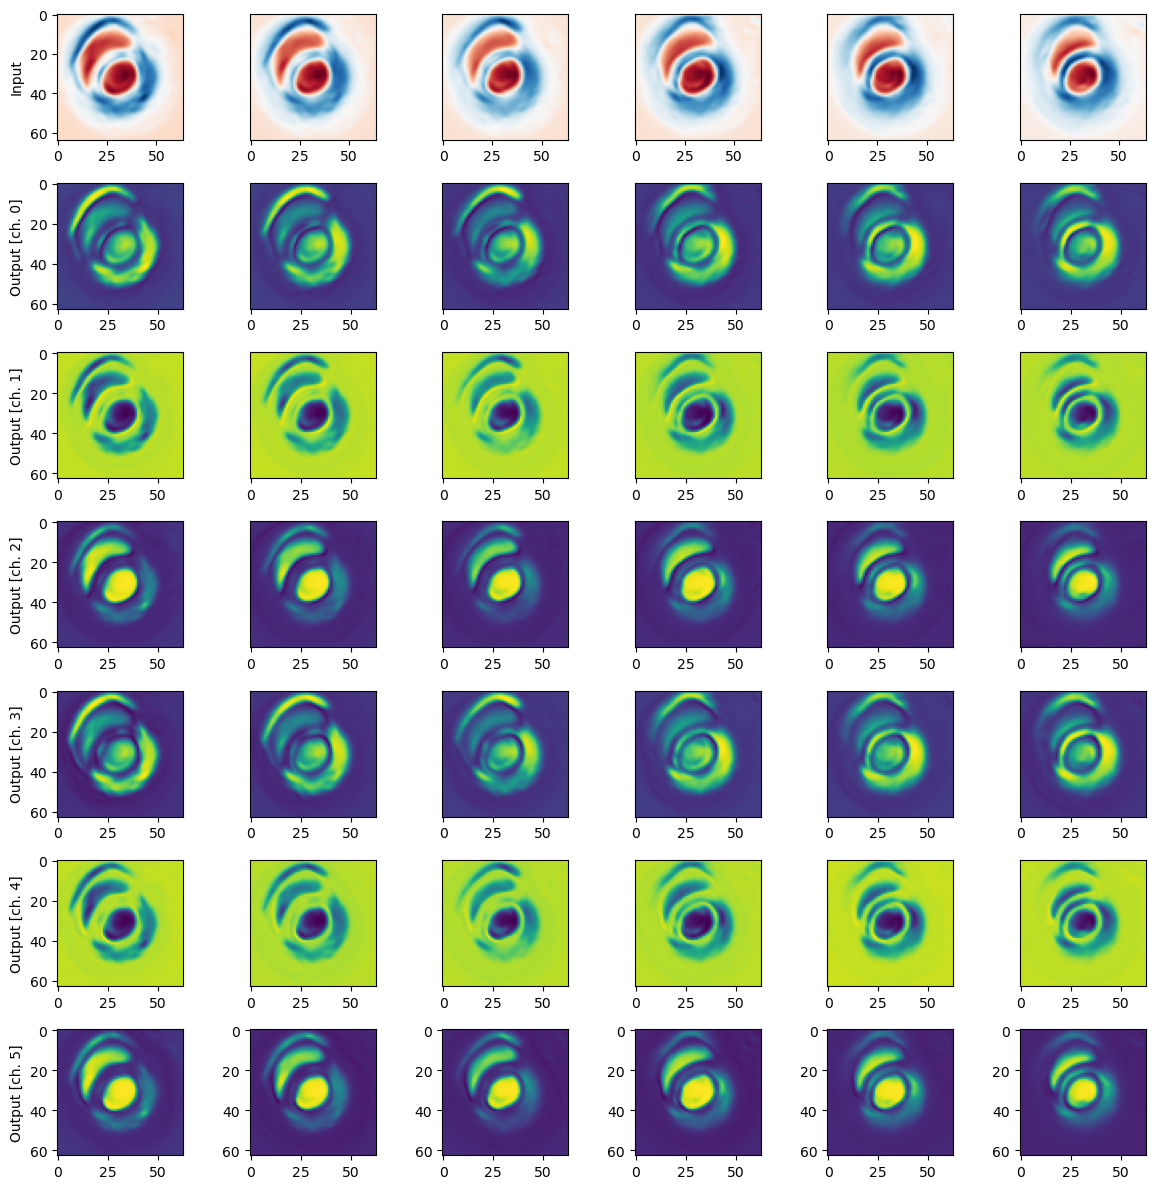

In [8]:
# PRINT SOME SAMPLES
n_samples = 6
n_channels = 6
fig, axes = plt.subplots(1 + n_channels, n_samples, figsize=(12, 12))
for k in range(n_samples):
    axes[0, 0].set_ylabel("Input")
    if k != 0:
        axes[0, k].yaxis.set_visible(False)
    axes[0, k].imshow(train_imgs_tf_rad[k, :, :, :])

    # Plot all output channels
    for c in range(n_channels):
        axes[c + 1, 0].set_ylabel("Output [ch. {}]".format(c))
        if k != 0:
            axes[c, k].yaxis.set_visible(False)
        axes[c + 1, k].imshow(q_train_images_rad[k, :, : ,c])

plt.tight_layout()
plt.show()

In [11]:
df_tr_rad[55:56]

,patient_name,class,image_type,img_number
119,MU_05,MU,radial,05


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


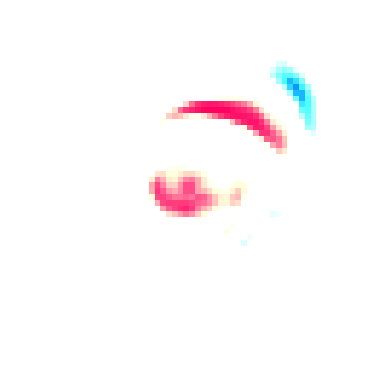

In [12]:
plt.imshow(train_imgs_tf_rad[55,:,:])
plt.axis('off')
plt.show()

# Modelos básicos

In [9]:
def cnn(input_size: list,learning_rate: float, activation: str, dropout: float, regularization: float, num_classes: int, num_layers: int, num_filters: list, filter_size: int, pool_size:int):
    """Initializes and returns a custom Keras model
    which is ready to be trained."""
    if len(num_filters) != num_layers:
        raise ValueError("Number of filters and number of layers should be the same.")
    
    layers = [
        keras.layers.Conv3D(24, (2,2,3), strides = 1, activation='relu', input_shape=(input_size[0],input_size[1],3,1)), #Convolucion que sustituye a la cuantica
        keras.layers.Reshape((input_size[0]-1, input_size[1]-1, 24))
        ]
    for i in range(num_layers):
        layers.append(keras.layers.Conv2D(num_filters[i], filter_size, strides=1, activation=activation, padding="same", kernel_regularizer=l2(regularization)))
        layers.append(keras.layers.BatchNormalization(momentum=0.98))
        layers.append(keras.layers.Dropout(dropout))
        layers.append(keras.layers.MaxPooling2D(pool_size=pool_size))
    layers.append(keras.layers.Flatten())
    layers.append(keras.layers.Dense(num_classes, activation="softmax"))

    model = keras.models.Sequential(layers)

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

def qcnn(input_size: list, learning_rate: float, activation: str, dropout: float, regularization: float, num_classes: int, num_layers: int, num_filters: list, filter_size: int, pool_size:int):
    """Initializes and returns a custom Keras model
    which is ready to be trained."""
    if len(num_filters) != num_layers:
        raise ValueError("Number of filters and number of layers should be the same.")
    layers = []
    for i in range(num_layers):
        if i == 0:
            layers.append(keras.layers.Conv2D(num_filters[i], filter_size, strides=1, activation=activation, padding="same", kernel_regularizer=l2(regularization), input_shape=(input_size[0]-1,input_size[1]-1,24)))
        else:
            layers.append(keras.layers.Conv2D(num_filters[i], filter_size, strides=1, activation=activation, padding="same", kernel_regularizer=l2(regularization)))
        layers.append(keras.layers.BatchNormalization(momentum=0.98))
        layers.append(keras.layers.Dropout(dropout))
        layers.append(keras.layers.MaxPooling2D(pool_size=pool_size))
    layers.append(keras.layers.Flatten())
    layers.append(keras.layers.Dense(num_classes, activation="softmax"))

    model = keras.models.Sequential(layers)

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

In [10]:
lr_callback = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=30, verbose=1)
early_stopping = EarlyStopping(monitor="val_loss", patience=100, restore_best_weights=True, verbose=1)

In [15]:
# Verifica las dimensiones de las imágenes de entrenamiento
print(f'q_train_images shape: {q_train_images.shape}')
print(f'q_val_images shape: {q_val_images.shape}')
print(f'train_imgs_tf shape: {train_imgs_tf.shape}')
print(f'val_imgs_tf shape: {val_imgs_tf.shape}')

q_train_images shape: (2784, 63, 63, 24)
q_val_images shape: (800, 63, 63, 24)
train_imgs_tf shape: (2784, 64, 64, 3)
val_imgs_tf shape: (800, 64, 64, 3)


# 2 clases

In [13]:
# Train
mask_circ = ~df_tr_circ["class"].isin(["MU","MCD"])
df_tr2_circ = df_tr_circ[mask_circ]
train_imgs_tf2_circ = train_imgs_tf_circ[mask_circ]
q_train_images2_circ = q_train_images_circ[mask_circ]

mask_rad = ~df_tr_rad["class"].isin(["MU","MCD"])
df_tr2_rad = df_tr_rad[mask_rad]
train_imgs_tf2_rad = train_imgs_tf_rad[mask_rad]
q_train_images2_rad = q_train_images_rad[mask_rad]

# Validation
mask_circ = ~df_val_circ["class"].isin(["MU","MCD"])
df_val2_circ = df_val_circ[mask_circ]
val_imgs_tf2_circ = val_imgs_tf_circ[mask_circ]
q_val_images2_circ = q_val_images_circ[mask_circ]

mask_rad = ~df_val_rad["class"].isin(["MU","MCD"])
df_val2_rad = df_val_rad[mask_rad]
val_imgs_tf2_rad = val_imgs_tf_rad[mask_rad]
q_val_images2_rad = q_val_images_rad[mask_rad]

# KFolds
mask_circ = ~df_circ["class"].isin(["MU","MCD"])
df2_circ = df_circ[mask_circ]
imgs_tf2_circ = imgs_tf_circ[mask_circ]
q_images2_circ = q_images_circ[mask_circ]

mask_rad = ~df_rad["class"].isin(["MU","MCD"])
df2_rad = df_rad[mask_rad]
imgs_tf2_rad = imgs_tf_rad[mask_rad]
q_images2_rad = q_images_rad[mask_rad]

# Test
mask_circ = ~df_test_circ["class"].isin(["MU","MCD"])
df_test2_circ = df_test_circ[mask_circ]
test_imgs_tf2_circ = test_imgs_tf_circ[mask_circ]
q_test_images2_circ = q_test_images_circ[mask_circ]

mask_rad = ~df_test_rad["class"].isin(["MU","MCD"])
df_test2_rad = df_test_rad[mask_rad]
test_imgs_tf2_rad = test_imgs_tf_rad[mask_rad]
q_test_images2_rad = q_test_images_rad[mask_rad]

In [ ]:
Encoder2=OneHotEncoder(sparse=False)
train_labels2_circ=Encoder2.fit_transform(df_tr2_circ["class"].values.reshape(-1, 1))
val_labels2_circ=Encoder2.fit_transform(df_val2_circ["class"].values.reshape(-1, 1))
test_labels2_circ=Encoder2.fit_transform(df_test2_circ["class"].values.reshape(-1, 1))
labels2_circ=Encoder2.fit_transform(df2_circ["class"].values.reshape(-1, 1))

train_labels2_rad=Encoder2.fit_transform(df_tr2_rad["class"].values.reshape(-1, 1))
val_labels2_rad=Encoder2.fit_transform(df_val2_rad["class"].values.reshape(-1, 1))
test_labels2_rad=Encoder2.fit_transform(df_test2_rad["class"].values.reshape(-1, 1))
labels2_rad=Encoder2.fit_transform(df2_rad["class"].values.reshape(-1, 1))

Encoder2.categories_

c:\Users\mateo\anaconda3\envs\tensor_gpu\lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
c:\Users\mateo\anaconda3\envs\tensor_gpu\lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
c:\Users\mateo\anaconda3\envs\tensor_gpu\lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
c:\Users\mateo\anaconda3\envs\tensor_gpu\lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was rename

[array(['C', 'MCA'], dtype=object)]

## QCNN

### KFold

In [ ]:
kf = KFold(n_splits=k, shuffle=True, random_state=random_seed)
kf.get_n_splits(q_images2_rad,labels2_rad)

5

In [27]:
histories = []
for fold, (train_idx, val_idx) in enumerate(kf.split(q_images2_rad,labels2_rad)):
    print(f"Entrenando fold {fold+1}/{k}...")
    
    # Dividir los datos en train y validation para este fold
    train_images, val_images = q_images2_rad[train_idx], q_images2_rad[val_idx]
    train_labels, val_labels = labels2_rad[train_idx], labels2_rad[val_idx]
    
    # Instanciar el modelo
    model = qcnn(
        input_size=[64, 64], 
        learning_rate=0.001, 
        activation='relu', 
        dropout=0.3, 
        regularization=0.001,
        num_classes=2, 
        num_layers=3, 
        num_filters=[4, 8, 16], 
        filter_size=3, 
        pool_size=2
    )
    
    checkpoint = ModelCheckpoint(f"checkpoints/qcnn_fold{fold+1}.h5", monitor="val_loss", save_best_only=True, verbose=1)
    
    # Entrenar el modelo
    history = model.fit(
        train_images,
        train_labels,
        validation_data=(val_images, val_labels),
        batch_size=512,
        epochs=500,
        verbose=2,
        callbacks=[checkpoint, lr_callback, early_stopping]
    )
    
    # Guardar el historial de entrenamiento
    with open(f"history/qcnn_fold{fold+1}.pkl", "wb") as f:
        pickle.dump(history.history, f)
    
    histories.append(history.history)

Entrenando fold 1/5...
Epoch 1/500

Epoch 1: val_loss improved from inf to 0.72586, saving model to checkpoints\qcnn_fold1.h5
2/2 - 9s - loss: 1.7447 - accuracy: 0.4876 - val_loss: 0.7259 - val_accuracy: 0.4851 - lr: 0.0010 - 9s/epoch - 4s/step
Epoch 2/500

Epoch 2: val_loss did not improve from 0.72586
2/2 - 0s - loss: 1.3359 - accuracy: 0.5459 - val_loss: 0.7288 - val_accuracy: 0.4851 - lr: 0.0010 - 129ms/epoch - 65ms/step
Epoch 3/500

Epoch 3: val_loss improved from 0.72586 to 0.72548, saving model to checkpoints\qcnn_fold1.h5
2/2 - 0s - loss: 1.2554 - accuracy: 0.5447 - val_loss: 0.7255 - val_accuracy: 0.4851 - lr: 0.0010 - 166ms/epoch - 83ms/step
Epoch 4/500

Epoch 4: val_loss improved from 0.72548 to 0.72466, saving model to checkpoints\qcnn_fold1.h5
2/2 - 0s - loss: 1.1660 - accuracy: 0.5422 - val_loss: 0.7247 - val_accuracy: 0.4851 - lr: 0.0010 - 161ms/epoch - 81ms/step
Epoch 5/500

Epoch 5: val_loss did not improve from 0.72466
2/2 - 0s - loss: 0.9764 - accuracy: 0.6228 - val_

In [ ]:
colors = ['b', 'g', 'r', 'c', 'm']
linestyles = ['-', '--', '-.', ':', '-']

# Gráfica de pérdida
plt.figure(figsize=(12, 5))
for i, history in enumerate(histories):
    plt.plot(history['loss'], label=f'Fold {i+1} (Train)', color=colors[i], linestyle=linestyles[0])
    plt.plot(history['val_loss'], label=f'Fold {i+1} (Val)', color=colors[i], linestyle=linestyles[1])

plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.title('Curvas de Pérdida por Fold')
plt.legend()
plt.grid()
plt.show()

# Gráfica de precisión
plt.figure(figsize=(12, 5))
for i, history in enumerate(histories):
    plt.plot(history['accuracy'], label=f'Fold {i+1} (Train)', color=colors[i], linestyle=linestyles[0])
    plt.plot(history['val_accuracy'], label=f'Fold {i+1} (Val)', color=colors[i], linestyle=linestyles[1])

plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.title('Curvas de Precisión por Fold')
plt.legend()
plt.grid()
plt.show()

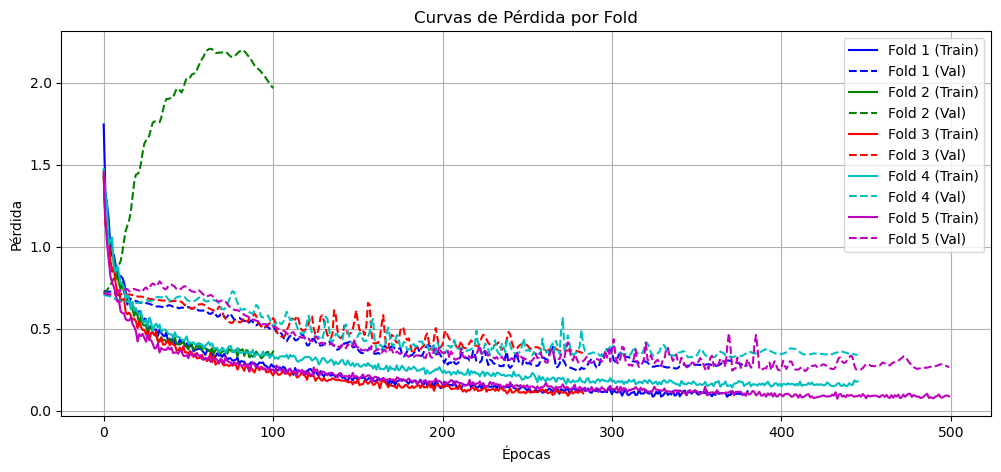

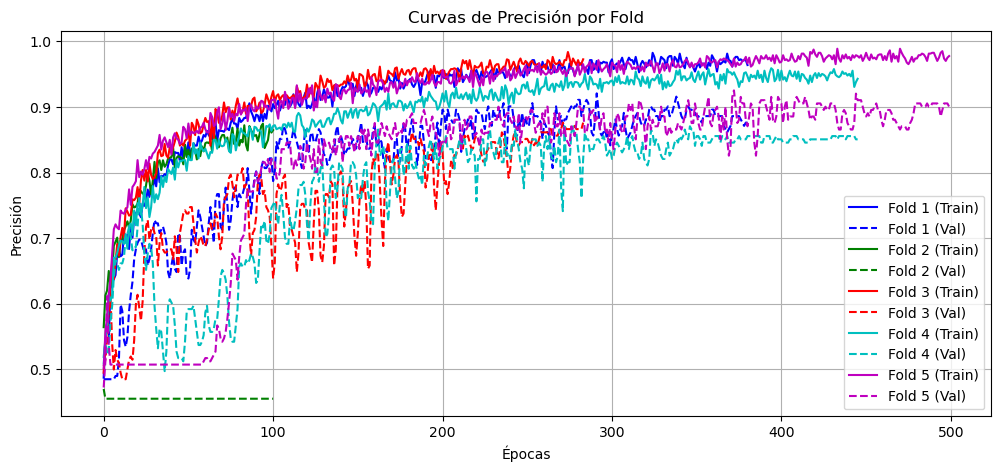

In [28]:
colors = ['b', 'g', 'r', 'c', 'm']
linestyles = ['-', '--', '-.', ':', '-']

# Gráfica de pérdida
plt.figure(figsize=(12, 5))
for i, history in enumerate(histories):
    plt.plot(history['loss'], label=f'Fold {i+1} (Train)', color=colors[i], linestyle=linestyles[0])
    plt.plot(history['val_loss'], label=f'Fold {i+1} (Val)', color=colors[i], linestyle=linestyles[1])

plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.title('Curvas de Pérdida por Fold')
plt.legend()
plt.grid()
plt.show()

# Gráfica de precisión
plt.figure(figsize=(12, 5))
for i, history in enumerate(histories):
    plt.plot(history['accuracy'], label=f'Fold {i+1} (Train)', color=colors[i], linestyle=linestyles[0])
    plt.plot(history['val_accuracy'], label=f'Fold {i+1} (Val)', color=colors[i], linestyle=linestyles[1])

plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.title('Curvas de Precisión por Fold')
plt.legend()
plt.grid()
plt.show()

### Normal

In [25]:
q_model = qcnn(
    input_size=[64,64], 
    learning_rate = 0.001, 
    activation = 'relu', 
    dropout = 0.3, 
    regularization=0.001,
    num_classes=2, 
    num_layers=3, 
    num_filters=[4,8,16], 
    filter_size=3, 
    pool_size=2)
checkpoint = ModelCheckpoint("checkpoints/qcnn_C_MCA.h5", monitor="val_loss", save_best_only=True, verbose=1)

q_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 63, 63, 4)         868       
                                                                 
 batch_normalization (BatchN  (None, 63, 63, 4)        16        
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 63, 63, 4)         0         
                                                                 
 max_pooling2d (MaxPooling2D  (None, 31, 31, 4)        0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 31, 31, 8)         296       
                                                                 
 batch_normalization_1 (Batc  (None, 31, 31, 8)        3

In [26]:
q_history = q_model.fit(
    q_train_images2_rad,
    train_labels2_rad,
    validation_data=(q_val_images2_rad, val_labels2_rad),
    batch_size=512,
    epochs=500,
    verbose=2,
    callbacks=[checkpoint, lr_callback, early_stopping]
)

with open("history/qcnn_C_MCA.pkl", "wb") as f:
    pickle.dump(q_history.history, f)

Epoch 1/500

Epoch 1: val_loss improved from inf to 0.72279, saving model to checkpoints\qcnn_C_MCA.h5
2/2 - 12s - loss: 1.4044 - accuracy: 0.5153 - val_loss: 0.7228 - val_accuracy: 0.4509 - lr: 0.0010 - 12s/epoch - 6s/step
Epoch 2/500

Epoch 2: val_loss improved from 0.72279 to 0.72047, saving model to checkpoints\qcnn_C_MCA.h5
2/2 - 0s - loss: 1.1655 - accuracy: 0.5370 - val_loss: 0.7205 - val_accuracy: 0.5000 - lr: 0.0010 - 215ms/epoch - 108ms/step
Epoch 3/500

Epoch 3: val_loss improved from 0.72047 to 0.71816, saving model to checkpoints\qcnn_C_MCA.h5
2/2 - 0s - loss: 1.0513 - accuracy: 0.5804 - val_loss: 0.7182 - val_accuracy: 0.5045 - lr: 0.0010 - 208ms/epoch - 104ms/step
Epoch 4/500

Epoch 4: val_loss improved from 0.71816 to 0.71671, saving model to checkpoints\qcnn_C_MCA.h5
2/2 - 0s - loss: 0.9236 - accuracy: 0.6161 - val_loss: 0.7167 - val_accuracy: 0.4777 - lr: 0.0010 - 204ms/epoch - 102ms/step
Epoch 5/500

Epoch 5: val_loss improved from 0.71671 to 0.71600, saving model to

4/4 [==============================] - 0s 12ms/step
AUC for class 1: 0.6038411458333334
AUC for class 2: 0.6038411458333333
Mean AUC: 0.6038411458333333
F1_Score: 0.5714285714285714
ACC: 0.5714285714285714


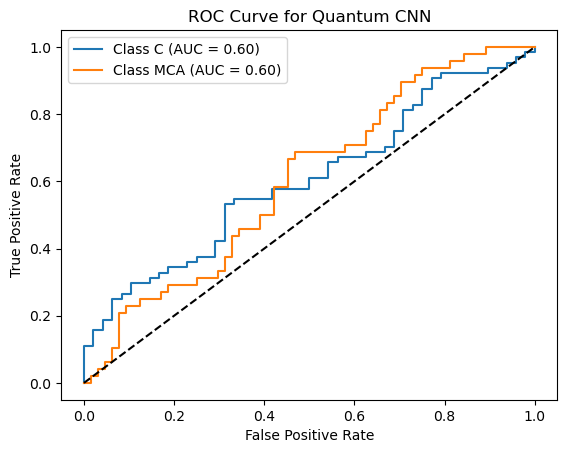

In [27]:
q_predictions=q_model.predict(q_test_images2_circ)
auc_scores = []
for i in range(test_labels2_circ.shape[1]):
    auc = roc_auc_score(test_labels2_circ[:, i], q_predictions[:, i])
    auc_scores.append(auc)
    print(f"AUC for class {i+1}:", auc)

# Promedio del AUC:
mean_auc = np.mean(auc_scores)
print("Mean AUC:", mean_auc)

# F1_Score y Accuracy (calculado como promedio micro):
f1 = f1_score(test_labels2_circ, np.round(q_predictions), average='micro')
print('F1_Score:', f1)

# Accuracy:
acc = accuracy_score(test_labels2_circ, np.round(q_predictions))
print('ACC:', acc)

# Si quieres también obtener las curvas ROC para cada clase:
fpr = dict()
tpr = dict()
thresholds = dict()

for i in range(test_labels2_circ.shape[1]):
    fpr[i], tpr[i], thresholds[i] = roc_curve(test_labels2_circ[:, i], q_predictions[:, i])


for i in range(test_labels2_circ.shape[1]):
    plt.plot(fpr[i], tpr[i], label=f'Class {Encoder2.categories_[0][i]} (AUC = {auc_scores[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Quantum CNN')
plt.legend(loc='best')
plt.show()

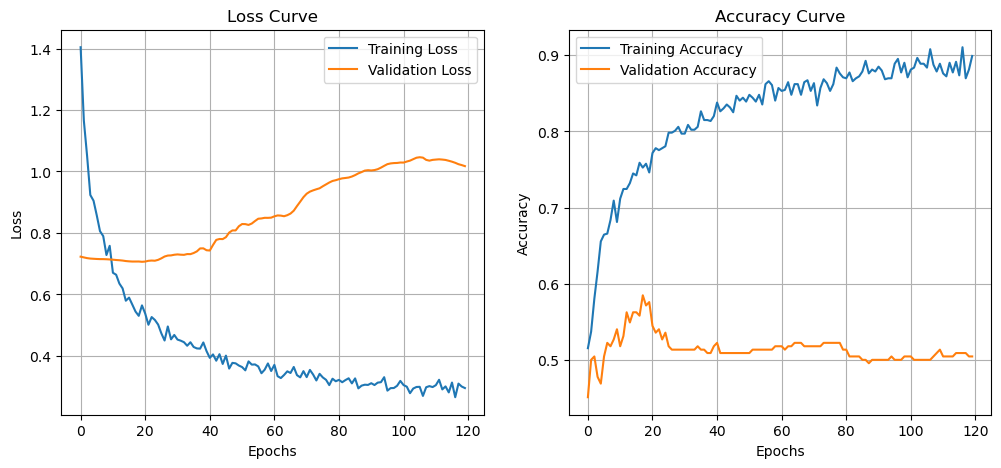

In [28]:
history = q_history.history

# Plot Loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()
plt.grid()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()
plt.grid()


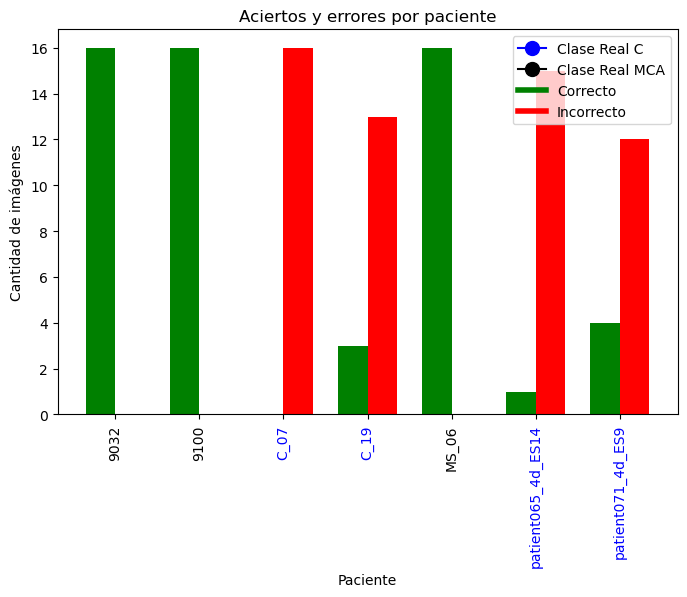

In [22]:
df = df_test2_circ.copy()
df["pred"] = [Encoder2.categories_[0][i] for i in q_predictions.argmax(axis=1)]
df["correct"] = df["pred"] == df["class"]
df_grouped = df.groupby("patient_name")["correct"].value_counts().unstack(fill_value=0)

# Graficar barras separadas con colores
fig, ax = plt.subplots(figsize=(8, 5))
bar_width = 0.35  # Separación de barras
x = np.arange(len(df_grouped))  # Posiciones en el eje X

# Graficar barras separadas
ax.bar(x - bar_width/2, df_grouped[True], width=bar_width, label="Correcto", color="green")
ax.bar(x + bar_width/2, df_grouped[False], width=bar_width, label="Incorrecto", color="red")

# Obtener colores para etiquetas del eje X
colores = ["blue" if df[df["patient_name"] == p]["class"].iloc[0] == "C" else "black" for p in df_grouped.index]

# Etiquetas y formato
ax.set_xticks(x)
ax.set_xticklabels(df_grouped.index)

# Cambiar color de cada etiqueta
for tick, color in zip(ax.get_xticklabels(), colores):
    tick.set_color(color)
plt.xticks(rotation=90)

ax.set_xlabel("Paciente")
ax.set_ylabel("Cantidad de imágenes")
ax.set_title("Aciertos y errores por paciente")
handle_azul = mlines.Line2D([], [], marker='o', color='blue', label='Clase Real C', markersize=10)
handle_negro = mlines.Line2D([], [], marker='o', color='black', label='Clase Real MCA', markersize=10)
handle_correcto = mlines.Line2D([], [], color='green', lw=4, label='Correcto')
handle_incorrecto = mlines.Line2D([], [], color='red', lw=4, label='Incorrecto')
ax.legend(handles=[handle_azul, handle_negro, handle_correcto, handle_incorrecto])

plt.show()

## CNN

### KFold

In [17]:
kf = KFold(n_splits=k, shuffle=True, random_state=random_seed)
kf.get_n_splits(imgs_tf2_rad,labels2_rad)

5

In [18]:
histories = []
for fold, (train_idx, val_idx) in enumerate(kf.split(imgs_tf2_rad,labels2_rad)):
    print(f"Entrenando fold {fold+1}/{k}...")
    
    # Dividir los datos en train y validation para este fold
    train_images, val_images = imgs_tf2_rad[train_idx], imgs_tf2_rad[val_idx]
    train_labels, val_labels = labels2_rad[train_idx], labels2_rad[val_idx]
    
    # Instanciar el modelo
    model = cnn(
        input_size=[64, 64], 
        learning_rate=0.001, 
        activation='relu', 
        dropout=0.3, 
        regularization=0.001,
        num_classes=2, 
        num_layers=3, 
        num_filters=[4, 8, 16], 
        filter_size=3, 
        pool_size=2
    )
    
    checkpoint = ModelCheckpoint(f"checkpoints/cnn_fold{fold+1}.h5", monitor="val_loss", save_best_only=True, verbose=1)
    
    # Entrenar el modelo
    history = model.fit(
        train_images,
        train_labels,
        validation_data=(val_images, val_labels),
        batch_size=512,
        epochs=500,
        verbose=2,
        callbacks=[checkpoint, lr_callback, early_stopping]
    )
    
    # Guardar el historial de entrenamiento
    with open(f"history/cnn_fold{fold+1}.pkl", "wb") as f:
        pickle.dump(history.history, f)
    
    histories.append(history.history)

Entrenando fold 1/5...
Epoch 1/500

Epoch 1: val_loss improved from inf to 0.71653, saving model to checkpoints\cnn_fold1.h5
2/2 - 12s - loss: 1.8555 - accuracy: 0.4752 - val_loss: 0.7165 - val_accuracy: 0.5149 - lr: 0.0010 - 12s/epoch - 6s/step
Epoch 2/500

Epoch 2: val_loss improved from 0.71653 to 0.71418, saving model to checkpoints\cnn_fold1.h5
2/2 - 0s - loss: 1.5365 - accuracy: 0.5136 - val_loss: 0.7142 - val_accuracy: 0.5198 - lr: 0.0010 - 139ms/epoch - 69ms/step
Epoch 3/500

Epoch 3: val_loss improved from 0.71418 to 0.71138, saving model to checkpoints\cnn_fold1.h5
2/2 - 0s - loss: 1.4109 - accuracy: 0.5273 - val_loss: 0.7114 - val_accuracy: 0.5594 - lr: 0.0010 - 141ms/epoch - 71ms/step
Epoch 4/500

Epoch 4: val_loss improved from 0.71138 to 0.70876, saving model to checkpoints\cnn_fold1.h5
2/2 - 0s - loss: 1.2708 - accuracy: 0.5261 - val_loss: 0.7088 - val_accuracy: 0.6485 - lr: 0.0010 - 140ms/epoch - 70ms/step
Epoch 5/500

Epoch 5: val_loss improved from 0.70876 to 0.70580,

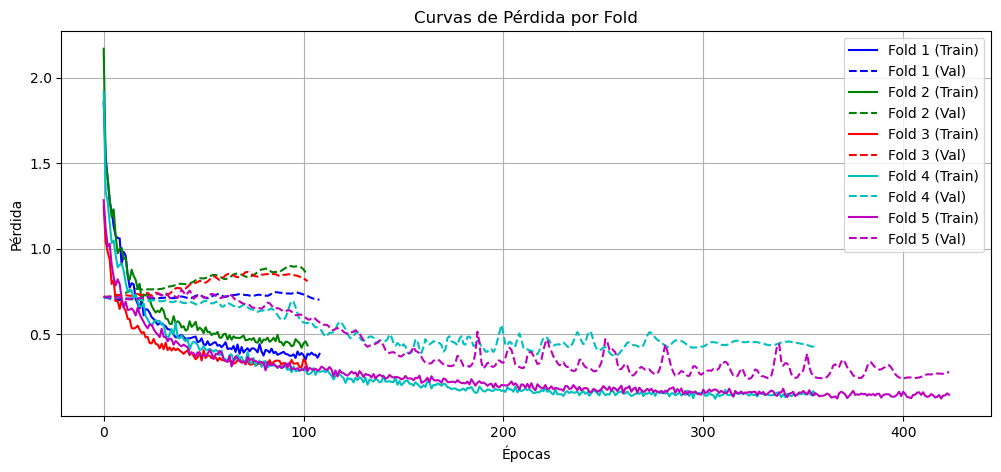

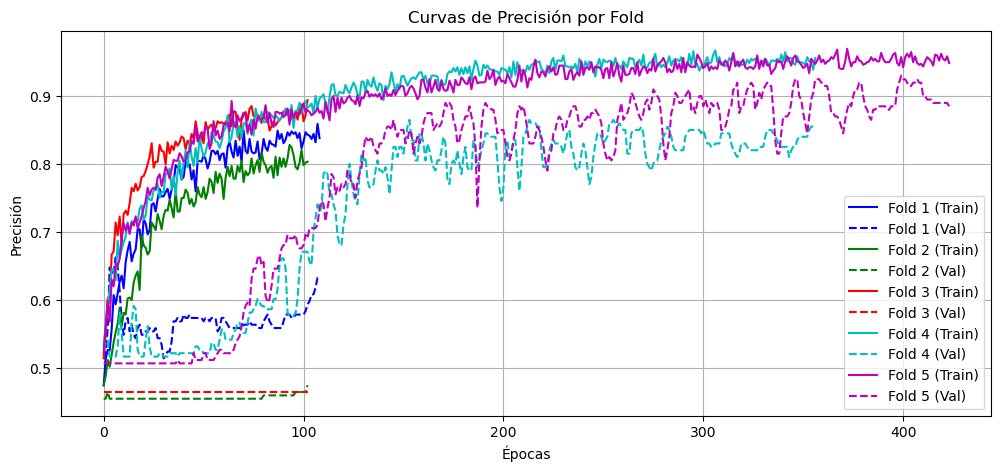

In [19]:
colors = ['b', 'g', 'r', 'c', 'm']
linestyles = ['-', '--', '-.', ':', '-']

# Gráfica de pérdida
plt.figure(figsize=(12, 5))
for i, history in enumerate(histories):
    plt.plot(history['loss'], label=f'Fold {i+1} (Train)', color=colors[i], linestyle=linestyles[0])
    plt.plot(history['val_loss'], label=f'Fold {i+1} (Val)', color=colors[i], linestyle=linestyles[1])

plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.title('Curvas de Pérdida por Fold')
plt.legend()
plt.grid()
plt.show()

# Gráfica de precisión
plt.figure(figsize=(12, 5))
for i, history in enumerate(histories):
    plt.plot(history['accuracy'], label=f'Fold {i+1} (Train)', color=colors[i], linestyle=linestyles[0])
    plt.plot(history['val_accuracy'], label=f'Fold {i+1} (Val)', color=colors[i], linestyle=linestyles[1])

plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.title('Curvas de Precisión por Fold')
plt.legend()
plt.grid()
plt.show()

### Normal

In [265]:
c_model = cnn(
    input_size=[64,64], 
    learning_rate = 0.001, 
    activation = 'relu', 
    dropout = 0.3, 
    regularization=0.001,
    num_classes=2, 
    num_layers=3, 
    num_filters=[4,8,16], 
    filter_size=3, 
    pool_size=2)
checkpoint = ModelCheckpoint("checkpoints/cnn_C_MCA.h5", monitor="val_loss", save_best_only=True, verbose=1)

c_model.summary()

Model: "sequential_64"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv3d_7 (Conv3D)           (None, 63, 63, 1, 24)     312       
                                                                 
 reshape_7 (Reshape)         (None, 63, 63, 24)        0         
                                                                 
 conv2d_195 (Conv2D)         (None, 63, 63, 4)         868       
                                                                 
 batch_normalization_195 (Ba  (None, 63, 63, 4)        16        
 tchNormalization)                                               
                                                                 
 dropout_195 (Dropout)       (None, 63, 63, 4)         0         
                                                                 
 max_pooling2d_195 (MaxPooli  (None, 31, 31, 4)        0         
 ng2D)                                               

In [266]:
c_history = c_model.fit(
    train_imgs_tf2_rad,
    train_labels2_rad,
    validation_data=(val_imgs_tf2_rad, val_labels2_rad),
    batch_size=512,
    epochs=500,
    verbose=2,
    callbacks=[checkpoint, lr_callback, early_stopping]
)
with open("history/cnn_C_MCA.pkl", "wb") as f:
    pickle.dump(q_history.history, f)

Epoch 1/500

Epoch 1: val_loss improved from inf to 0.71644, saving model to checkpoints\cnn_C_MCA.h5
2/2 - 1s - loss: 1.6280 - accuracy: 0.4974 - val_loss: 0.7164 - val_accuracy: 0.5045 - lr: 0.0010 - 887ms/epoch - 444ms/step
Epoch 2/500

Epoch 2: val_loss improved from 0.71644 to 0.71622, saving model to checkpoints\cnn_C_MCA.h5
2/2 - 0s - loss: 1.3620 - accuracy: 0.5051 - val_loss: 0.7162 - val_accuracy: 0.4821 - lr: 0.0010 - 131ms/epoch - 65ms/step
Epoch 3/500

Epoch 3: val_loss did not improve from 0.71622
2/2 - 0s - loss: 1.2792 - accuracy: 0.5459 - val_loss: 0.7167 - val_accuracy: 0.5000 - lr: 0.0010 - 96ms/epoch - 48ms/step
Epoch 4/500

Epoch 4: val_loss did not improve from 0.71622
2/2 - 0s - loss: 1.1575 - accuracy: 0.5906 - val_loss: 0.7177 - val_accuracy: 0.5000 - lr: 0.0010 - 94ms/epoch - 47ms/step
Epoch 5/500

Epoch 5: val_loss did not improve from 0.71622
2/2 - 0s - loss: 1.1322 - accuracy: 0.5740 - val_loss: 0.7185 - val_accuracy: 0.5000 - lr: 0.0010 - 94ms/epoch - 47ms

4/4 [==============================] - 0s 2ms/step
AUC for class 1: 0.5188802083333333
AUC for class 2: 0.5188802083333334
Mean AUC: 0.5188802083333333
F1_Score: 0.4642857142857143
ACC: 0.4642857142857143


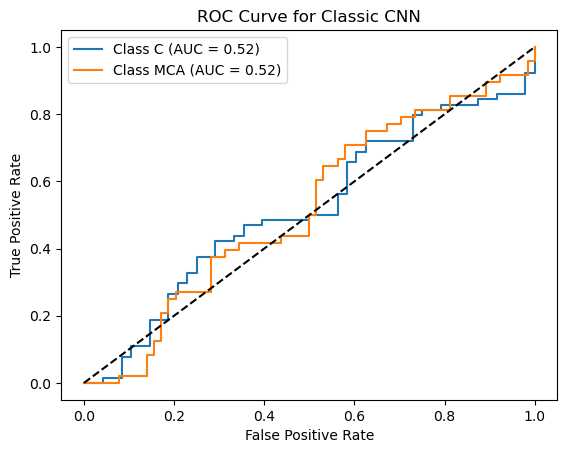

In [267]:
c_predictions=c_model.predict(test_imgs_tf2_circ)
auc_scores = []
for i in range(test_labels2_circ.shape[1]):
    auc = roc_auc_score(test_labels2_circ[:, i], c_predictions[:, i])
    auc_scores.append(auc)
    print(f"AUC for class {i+1}:", auc)

# Promedio del AUC:
mean_auc = np.mean(auc_scores)
print("Mean AUC:", mean_auc)

# F1_Score y Accuracy (calculado como promedio micro):
f1 = f1_score(test_labels2_circ, np.round(c_predictions), average='micro')
print('F1_Score:', f1)

# Accuracy:
acc = accuracy_score(test_labels2_circ, np.round(c_predictions))
print('ACC:', acc)

# Si quieres también obtener las curvas ROC para cada clase:
fpr = dict()
tpr = dict()
thresholds = dict()

for i in range(test_labels2_circ.shape[1]):
    fpr[i], tpr[i], thresholds[i] = roc_curve(test_labels2_circ[:, i], c_predictions[:, i])


for i in range(test_labels2_circ.shape[1]):
    plt.plot(fpr[i], tpr[i], label=f'Class {Encoder2.categories_[0][i]} (AUC = {auc_scores[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Classic CNN')
plt.legend(loc='best')
plt.show()

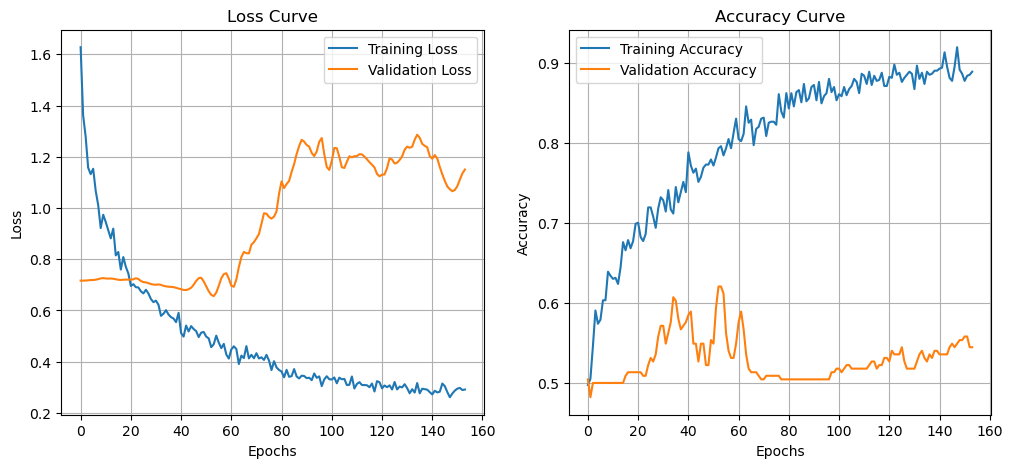

In [269]:
history = c_history.history

# Plot Loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()
plt.grid()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()
plt.grid()

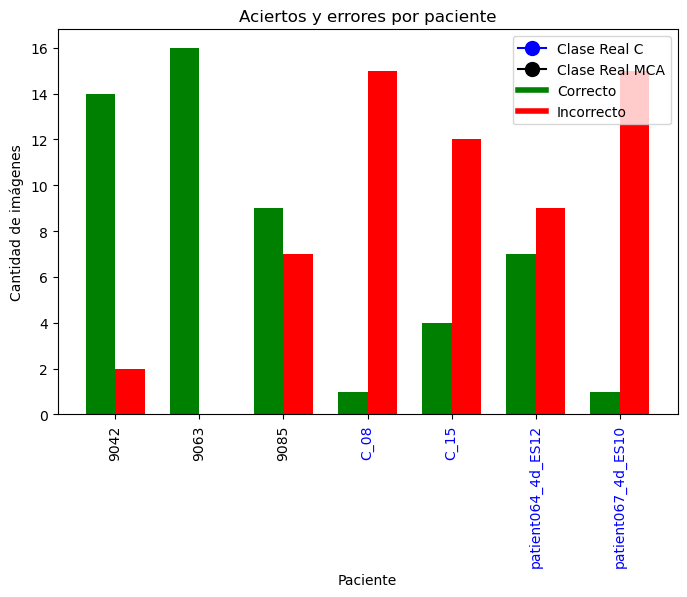

In [270]:
df = df_test2_circ.copy()
df["pred"] = [Encoder2.categories_[0][i] for i in c_predictions.argmax(axis=1)]
df["correct"] = df["pred"] == df["class"]
df_grouped = df.groupby("patient_name")["correct"].value_counts().unstack(fill_value=0)

# Graficar barras separadas con colores
fig, ax = plt.subplots(figsize=(8, 5))
bar_width = 0.35  # Separación de barras
x = np.arange(len(df_grouped))  # Posiciones en el eje X

# Graficar barras separadas
ax.bar(x - bar_width/2, df_grouped[True], width=bar_width, label="Correcto", color="green")
ax.bar(x + bar_width/2, df_grouped[False], width=bar_width, label="Incorrecto", color="red")

# Obtener colores para etiquetas del eje X
colores = ["blue" if df[df["patient_name"] == p]["class"].iloc[0] == "C" else "black" for p in df_grouped.index]

# Etiquetas y formato
ax.set_xticks(x)
ax.set_xticklabels(df_grouped.index)

# Cambiar color de cada etiqueta
for tick, color in zip(ax.get_xticklabels(), colores):
    tick.set_color(color)
plt.xticks(rotation=90)

ax.set_xlabel("Paciente")
ax.set_ylabel("Cantidad de imágenes")
ax.set_title("Aciertos y errores por paciente")
handle_azul = mlines.Line2D([], [], marker='o', color='blue', label='Clase Real C', markersize=10)
handle_negro = mlines.Line2D([], [], marker='o', color='black', label='Clase Real MCA', markersize=10)
handle_correcto = mlines.Line2D([], [], color='green', lw=4, label='Correcto')
handle_incorrecto = mlines.Line2D([], [], color='red', lw=4, label='Incorrecto')
ax.legend(handles=[handle_azul, handle_negro, handle_correcto, handle_incorrecto])

plt.show()

# 3 clases

In [13]:
mask_circ = ~df_tr_circ["class"].isin(["MU"])
df_tr2_circ = df_tr_circ[mask_circ]
train_imgs_tf2_circ = train_imgs_tf_circ[mask_circ]
q_train_images2_circ = q_train_images_circ[mask_circ]

mask_rad = ~df_tr_rad["class"].isin(["MU"])
df_tr2_rad = df_tr_rad[mask_rad]
train_imgs_tf2_rad = train_imgs_tf_rad[mask_rad]
q_train_images2_rad = q_train_images_rad[mask_rad]

mask_circ = ~df_val_circ["class"].isin(["MU"])
df_val2_circ = df_val_circ[mask_circ]
val_imgs_tf2_circ = val_imgs_tf_circ[mask_circ]
q_val_images2_circ = q_val_images_circ[mask_circ]

mask_rad = ~df_val_rad["class"].isin(["MU"])
df_val2_rad = df_val_rad[mask_rad]
val_imgs_tf2_rad = val_imgs_tf_rad[mask_rad]
q_val_images2_rad = q_val_images_rad[mask_rad]

mask_circ = ~df_test_circ["class"].isin(["MU"])
df_test2_circ = df_test_circ[mask_circ]
test_imgs_tf2_circ = test_imgs_tf_circ[mask_circ]
q_test_images2_circ = q_test_images_circ[mask_circ]

mask_rad = ~df_test_rad["class"].isin(["MU"])
df_test2_rad = df_test_rad[mask_rad]
test_imgs_tf2_rad = test_imgs_tf_rad[mask_rad]
q_test_images2_rad = q_test_images_rad[mask_rad]

# KFolds
mask_circ = ~df_circ["class"].isin(["MU"])
df2_circ = df_circ[mask_circ]
imgs_tf2_circ = imgs_tf_circ[mask_circ]
q_images2_circ = q_images_circ[mask_circ]

mask_rad = ~df_rad["class"].isin(["MU"])
df2_rad = df_rad[mask_rad]
imgs_tf2_rad = imgs_tf_rad[mask_rad]
q_images2_rad = q_images_rad[mask_rad]

In [14]:
Encoder2=OneHotEncoder(sparse=False)
train_labels2_circ=Encoder2.fit_transform(df_tr2_circ["class"].values.reshape(-1, 1))
val_labels2_circ=Encoder2.fit_transform(df_val2_circ["class"].values.reshape(-1, 1))
test_labels2_circ=Encoder2.fit_transform(df_test2_circ["class"].values.reshape(-1, 1))

labels2_circ=Encoder2.fit_transform(df2_circ["class"].values.reshape(-1, 1))
labels2_rad=Encoder2.fit_transform(df2_rad["class"].values.reshape(-1, 1))

Encoder2.categories_

c:\Users\mateo\anaconda3\envs\tensor_gpu\lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
c:\Users\mateo\anaconda3\envs\tensor_gpu\lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
c:\Users\mateo\anaconda3\envs\tensor_gpu\lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
c:\Users\mateo\anaconda3\envs\tensor_gpu\lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was rename

[array(['C', 'MCA', 'MCD'], dtype=object)]

## QCNN

In [15]:
kf = KFold(n_splits=k, shuffle=True, random_state=random_seed)
kf.get_n_splits(q_images2_rad,labels2_rad)

histories = []
for fold, (train_idx, val_idx) in enumerate(kf.split(q_images2_rad,labels2_rad)):
    print(f"Entrenando fold {fold+1}/{k}...")
    
    # Dividir los datos en train y validation para este fold
    train_images, val_images = q_images2_rad[train_idx], q_images2_rad[val_idx]
    train_labels, val_labels = labels2_rad[train_idx], labels2_rad[val_idx]
    
    # Instanciar el modelo
    model = qcnn(
        input_size=[64,64], 
        learning_rate = 0.001, 
        activation = 'relu', 
        dropout = 0.3, 
        regularization=0.001,
        num_classes=3, 
        num_layers=4, 
        num_filters=[4,8,16,32], 
        filter_size=2, 
        pool_size=2)
    
    checkpoint = ModelCheckpoint(f"checkpoints/qcnn_fold{fold+1}_3clases.h5", monitor="val_loss", save_best_only=True, verbose=1)
    
    # Entrenar el modelo
    history = model.fit(
        train_images,
        train_labels,
        validation_data=(val_images, val_labels),
        batch_size=512,
        epochs=500,
        verbose=2,
        callbacks=[checkpoint, lr_callback, early_stopping]
    )
    
    # Guardar el historial de entrenamiento
    with open(f"history/qcnn_fold{fold+1}_3clases.pkl", "wb") as f:
        pickle.dump(history.history, f)
    
    histories.append(history.history)

Entrenando fold 1/5...
Epoch 1/500

Epoch 1: val_loss improved from inf to 1.14899, saving model to checkpoints\qcnn_fold1_3clases.h5
3/3 - 11s - loss: 2.6838 - accuracy: 0.3468 - val_loss: 1.1490 - val_accuracy: 0.3088 - lr: 0.0010 - 11s/epoch - 4s/step
Epoch 2/500

Epoch 2: val_loss did not improve from 1.14899
3/3 - 0s - loss: 2.2867 - accuracy: 0.3468 - val_loss: 1.1552 - val_accuracy: 0.3088 - lr: 0.0010 - 263ms/epoch - 88ms/step
Epoch 3/500

Epoch 3: val_loss did not improve from 1.14899
3/3 - 0s - loss: 2.1024 - accuracy: 0.3565 - val_loss: 1.1602 - val_accuracy: 0.3088 - lr: 0.0010 - 264ms/epoch - 88ms/step
Epoch 4/500

Epoch 4: val_loss did not improve from 1.14899
3/3 - 0s - loss: 1.9477 - accuracy: 0.3538 - val_loss: 1.1675 - val_accuracy: 0.3088 - lr: 0.0010 - 263ms/epoch - 88ms/step
Epoch 5/500

Epoch 5: val_loss did not improve from 1.14899
3/3 - 0s - loss: 1.7970 - accuracy: 0.4012 - val_loss: 1.1762 - val_accuracy: 0.3088 - lr: 0.0010 - 207ms/epoch - 69ms/step
Epoch 6/5

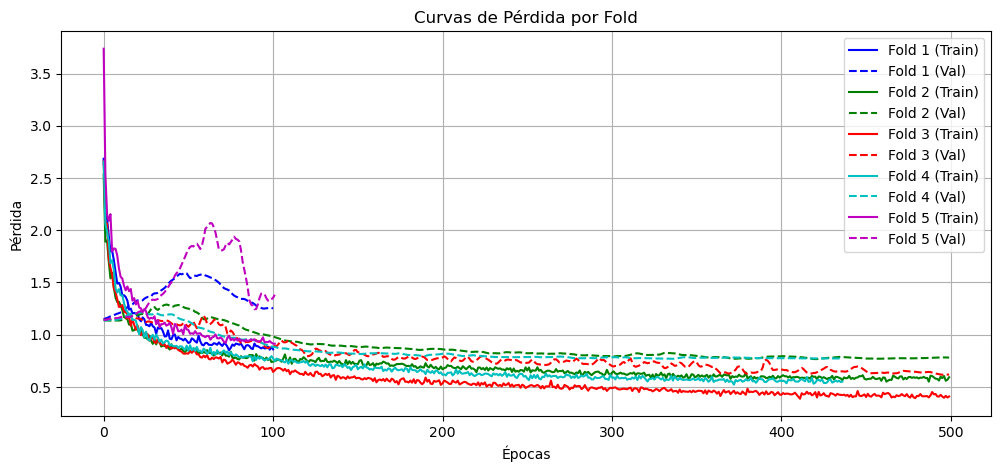

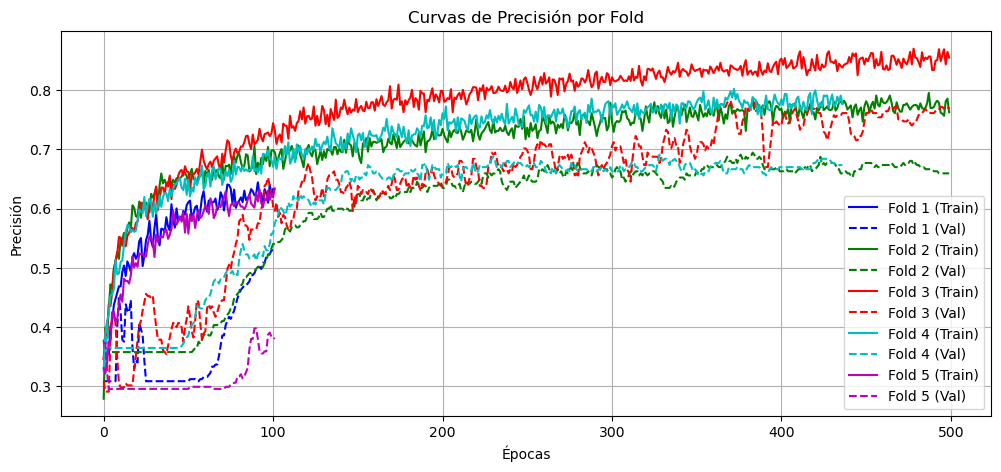

In [16]:
colors = ['b', 'g', 'r', 'c', 'm']
linestyles = ['-', '--', '-.', ':', '-']

# Gráfica de pérdida
plt.figure(figsize=(12, 5))
for i, history in enumerate(histories):
    plt.plot(history['loss'], label=f'Fold {i+1} (Train)', color=colors[i], linestyle=linestyles[0])
    plt.plot(history['val_loss'], label=f'Fold {i+1} (Val)', color=colors[i], linestyle=linestyles[1])

plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.title('Curvas de Pérdida por Fold')
plt.legend()
plt.grid()
plt.show()

# Gráfica de precisión
plt.figure(figsize=(12, 5))
for i, history in enumerate(histories):
    plt.plot(history['accuracy'], label=f'Fold {i+1} (Train)', color=colors[i], linestyle=linestyles[0])
    plt.plot(history['val_accuracy'], label=f'Fold {i+1} (Val)', color=colors[i], linestyle=linestyles[1])

plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.title('Curvas de Precisión por Fold')
plt.legend()
plt.grid()
plt.show()

In [63]:
q_model = qcnn(
    input_size=[64,64], 
    learning_rate = 0.001, 
    activation = 'relu', 
    dropout = 0.3, 
    regularization=0.001,
    num_classes=3, 
    num_layers=4, 
    num_filters=[4,8,16,32], 
    filter_size=2, 
    pool_size=2)
checkpoint = ModelCheckpoint("checkpoints/qcnn_C_MCA_MCD.h5", monitor="val_loss", save_best_only=True, verbose=1)

q_model.summary()

Model: "sequential_13"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_41 (Conv2D)          (None, 63, 63, 4)         388       
                                                                 
 batch_normalization_41 (Bat  (None, 63, 63, 4)        16        
 chNormalization)                                                
                                                                 
 dropout_41 (Dropout)        (None, 63, 63, 4)         0         
                                                                 
 max_pooling2d_41 (MaxPoolin  (None, 31, 31, 4)        0         
 g2D)                                                            
                                                                 
 conv2d_42 (Conv2D)          (None, 31, 31, 8)         136       
                                                                 
 batch_normalization_42 (Bat  (None, 31, 31, 8)      

In [64]:
q_history = q_model.fit(
    q_train_images2_circ,
    train_labels2_circ,
    validation_data=(q_val_images2_circ, val_labels2_circ),
    batch_size=512,
    epochs=500,
    verbose=2,
    callbacks=[checkpoint, lr_callback, early_stopping]
)

Epoch 1/500

Epoch 1: val_loss improved from inf to 1.13664, saving model to checkpoints\qcnn_C_MCA_MCD.h5
3/3 - 1s - loss: 3.0543 - accuracy: 0.2917 - val_loss: 1.1366 - val_accuracy: 0.4219 - lr: 0.0010 - 1s/epoch - 364ms/step
Epoch 2/500

Epoch 2: val_loss did not improve from 1.13664
3/3 - 0s - loss: 2.2815 - accuracy: 0.3442 - val_loss: 1.1369 - val_accuracy: 0.3938 - lr: 0.0010 - 197ms/epoch - 66ms/step
Epoch 3/500

Epoch 3: val_loss did not improve from 1.13664
3/3 - 0s - loss: 2.2390 - accuracy: 0.3795 - val_loss: 1.1374 - val_accuracy: 0.4031 - lr: 0.0010 - 199ms/epoch - 66ms/step
Epoch 4/500

Epoch 4: val_loss did not improve from 1.13664
3/3 - 0s - loss: 2.1949 - accuracy: 0.3687 - val_loss: 1.1369 - val_accuracy: 0.3844 - lr: 0.0010 - 193ms/epoch - 64ms/step
Epoch 5/500

Epoch 5: val_loss improved from 1.13664 to 1.13566, saving model to checkpoints\qcnn_C_MCA_MCD.h5
3/3 - 0s - loss: 2.0742 - accuracy: 0.3659 - val_loss: 1.1357 - val_accuracy: 0.3688 - lr: 0.0010 - 233ms/ep

5/5 [==============================] - 0s 34ms/step
AUC for class 1: 0.7449544270833334
AUC for class 2: 0.7247023809523809
AUC for class 3: 0.7561383928571429
Mean AUC: 0.7419317336309524
F1_Score: 0.4542124542124542
ACC: 0.3875


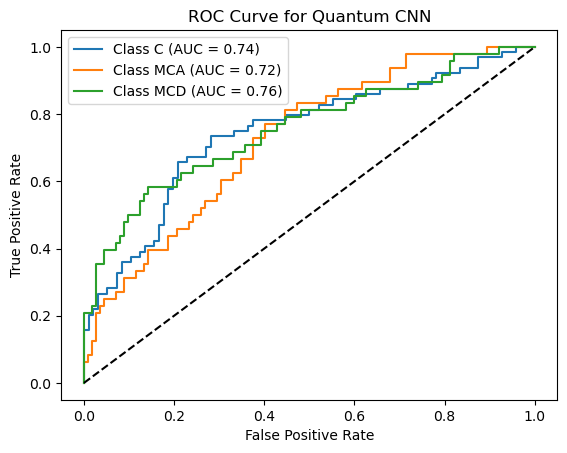

In [65]:
q_predictions=q_model.predict(q_test_images2_circ)
auc_scores = []
for i in range(test_labels2_circ.shape[1]):
    auc = roc_auc_score(test_labels2_circ[:, i], q_predictions[:, i])
    auc_scores.append(auc)
    print(f"AUC for class {i+1}:", auc)

# Promedio del AUC:
mean_auc = np.mean(auc_scores)
print("Mean AUC:", mean_auc)

# F1_Score y Accuracy (calculado como promedio micro):
f1 = f1_score(test_labels2_circ, np.round(q_predictions), average='micro')
print('F1_Score:', f1)

# Accuracy:
acc = accuracy_score(test_labels2_circ, np.round(q_predictions))
print('ACC:', acc)

# Si quieres también obtener las curvas ROC para cada clase:
fpr = dict()
tpr = dict()
thresholds = dict()

for i in range(test_labels2_circ.shape[1]):
    fpr[i], tpr[i], thresholds[i] = roc_curve(test_labels2_circ[:, i], q_predictions[:, i])

for i in range(test_labels2_circ.shape[1]):
    plt.plot(fpr[i], tpr[i], label=f'Class {Encoder2.categories_[0][i]} (AUC = {auc_scores[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Quantum CNN')
plt.legend(loc='best')
plt.show()


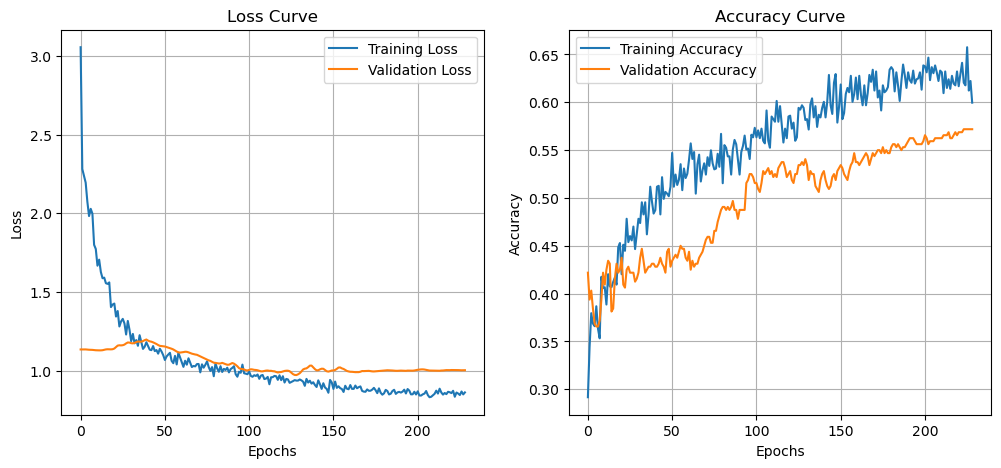

In [66]:
history = q_history.history

# Plot Loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()
plt.grid()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()
plt.grid()

plt.show()

## CNN

In [ ]:
kf = KFold(n_splits=k, shuffle=True, random_state=random_seed)
kf.get_n_splits(imgs_tf2_rad,labels2_rad)

histories = []
for fold, (train_idx, val_idx) in enumerate(kf.split(imgs_tf2_rad,labels2_rad)):
    print(f"Entrenando fold {fold+1}/{k}...")
    
    # Dividir los datos en train y validation para este fold
    train_images, val_images = imgs_tf2_rad[train_idx], imgs_tf2_rad[val_idx]
    train_labels, val_labels = labels2_rad[train_idx], labels2_rad[val_idx]
    
    # Instanciar el modelo
    model = cnn(
        input_size=[64,64], 
        learning_rate = 0.001, 
        activation = 'relu', 
        dropout = 0.3, 
        regularization=0.001,
        num_classes=3, 
        num_layers=4, 
        num_filters=[4,8,16,32], 
        filter_size=2, 
        pool_size=2)
    
    checkpoint = ModelCheckpoint(f"checkpoints/cnn_fold{fold+1}_3clases.h5", monitor="val_loss", save_best_only=True, verbose=1)
    
    # Entrenar el modelo
    history = model.fit(
        train_images,
        train_labels,
        validation_data=(val_images, val_labels),
        batch_size=512,
        epochs=500,
        verbose=2,
        callbacks=[checkpoint, lr_callback, early_stopping]
    )
    
    # Guardar el historial de entrenamiento
    with open(f"history/cnn_fold{fold+1}_3clases.pkl", "wb") as f:
        pickle.dump(history.history, f)
    
    histories.append(history.history)

In [67]:
mask = ~df_tr["class"].isin(["MU"])
df_tr2 = df_tr[mask]
train_imgs_tf2 = train_imgs_tf[mask]

mask = ~df_val["class"].isin(["MU"])
df_val2 = df_val[mask]
val_imgs_tf2 = val_imgs_tf[mask]

mask = ~df_test["class"].isin(["MU"])
df_test2 = df_test[mask]
test_imgs_tf2 = test_imgs_tf[mask]

In [68]:
Encoder2=OneHotEncoder(sparse=False)
train_labels2=Encoder2.fit_transform(df_tr2["class"].values.reshape(-1, 1))
val_labels2=Encoder2.fit_transform(df_val2["class"].values.reshape(-1, 1))
test_labels2=Encoder2.fit_transform(df_test2["class"].values.reshape(-1, 1))

Encoder2.categories_

c:\Users\mateo\anaconda3\envs\tensor_gpu\lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
c:\Users\mateo\anaconda3\envs\tensor_gpu\lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
c:\Users\mateo\anaconda3\envs\tensor_gpu\lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


[array(['C', 'MCA', 'MCD'], dtype=object)]

In [70]:
c_model = cnn(
    input_size=[64,64], 
    learning_rate = 0.001, 
    activation = 'relu', 
    dropout = 0.3, 
    regularization=0.001,
    num_classes=3, 
    num_layers=4, 
    num_filters=[4,8,16,32], 
    filter_size=2, 
    pool_size=2)
lr_callback = ReduceLROnPlateau(monitor='val_loss', factor=0.6, patience=20, verbose=1)
checkpoint = ModelCheckpoint("checkpoints/cnn_C_MCA_MCD.h5", monitor="val_loss", save_best_only=True, verbose=1)

c_model.summary()

Model: "sequential_14"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv3d_4 (Conv3D)           (None, 63, 63, 1, 24)     312       
                                                                 
 reshape_4 (Reshape)         (None, 63, 63, 24)        0         
                                                                 
 conv2d_45 (Conv2D)          (None, 63, 63, 4)         388       
                                                                 
 batch_normalization_45 (Bat  (None, 63, 63, 4)        16        
 chNormalization)                                                
                                                                 
 dropout_45 (Dropout)        (None, 63, 63, 4)         0         
                                                                 
 max_pooling2d_45 (MaxPoolin  (None, 31, 31, 4)        0         
 g2D)                                                

In [71]:
c_history = c_model.fit(
    train_imgs_tf2,
    train_labels2,
    validation_data=(val_imgs_tf2, val_labels2),
    batch_size=512,
    epochs=500,
    verbose=2,
    callbacks=[checkpoint, lr_callback, early_stopping]
)

Epoch 1/500

Epoch 1: val_loss improved from inf to 1.13867, saving model to checkpoints\cnn_C_MCA_MCD.h5
5/5 - 1s - loss: 2.4703 - accuracy: 0.3261 - val_loss: 1.1387 - val_accuracy: 0.3844 - lr: 0.0010 - 1s/epoch - 265ms/step
Epoch 2/500

Epoch 2: val_loss improved from 1.13867 to 1.13835, saving model to checkpoints\cnn_C_MCA_MCD.h5
5/5 - 0s - loss: 2.1475 - accuracy: 0.3469 - val_loss: 1.1383 - val_accuracy: 0.3625 - lr: 0.0010 - 339ms/epoch - 68ms/step
Epoch 3/500

Epoch 3: val_loss improved from 1.13835 to 1.13813, saving model to checkpoints\cnn_C_MCA_MCD.h5
5/5 - 0s - loss: 1.9486 - accuracy: 0.3718 - val_loss: 1.1381 - val_accuracy: 0.3688 - lr: 0.0010 - 339ms/epoch - 68ms/step
Epoch 4/500

Epoch 4: val_loss did not improve from 1.13813
5/5 - 0s - loss: 1.7984 - accuracy: 0.3764 - val_loss: 1.1394 - val_accuracy: 0.3656 - lr: 0.0010 - 293ms/epoch - 59ms/step
Epoch 5/500

Epoch 5: val_loss did not improve from 1.13813
5/5 - 0s - loss: 1.7196 - accuracy: 0.3895 - val_loss: 1.142

In [72]:
c_predictions=c_model.predict(test_imgs_tf2)

10/10 [==============================] - 0s 2ms/step


AUC for class 1: 0.720458984375
AUC for class 2: 0.6642950148809524
AUC for class 3: 0.5775204613095238
Mean AUC: 0.6540914868551587
F1_Score: 0.4620938628158845
ACC: 0.4


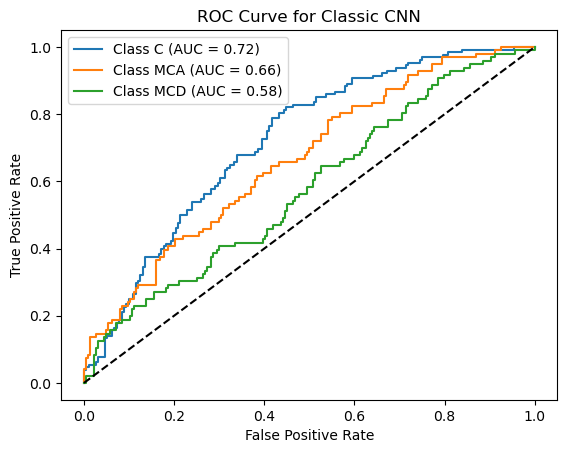

In [73]:
auc_scores = []
for i in range(test_labels2.shape[1]):
    auc = roc_auc_score(test_labels2[:, i], c_predictions[:, i])
    auc_scores.append(auc)
    print(f"AUC for class {i+1}:", auc)

# Promedio del AUC:
mean_auc = np.mean(auc_scores)
print("Mean AUC:", mean_auc)

# F1_Score y Accuracy (calculado como promedio micro):
f1 = f1_score(test_labels2, np.round(c_predictions), average='micro')
print('F1_Score:', f1)

# Accuracy:
acc = accuracy_score(test_labels2, np.round(c_predictions))
print('ACC:', acc)

# Si quieres también obtener las curvas ROC para cada clase:
fpr = dict()
tpr = dict()
thresholds = dict()

for i in range(test_labels2.shape[1]):
    fpr[i], tpr[i], thresholds[i] = roc_curve(test_labels2[:, i], c_predictions[:, i])


for i in range(test_labels2.shape[1]):
    plt.plot(fpr[i], tpr[i], label=f'Class {Encoder2.categories_[0][i]} (AUC = {auc_scores[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Classic CNN')
plt.legend(loc='best')
plt.show()


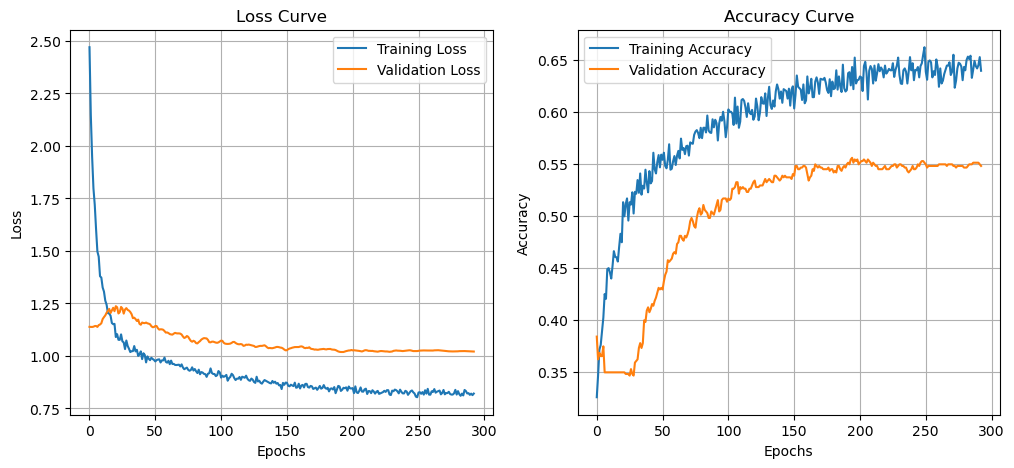

In [74]:
history = c_history.history

# Plot Loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()
plt.grid()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()
plt.grid()

plt.show()

In [ ]:
y_pred_probs = c_model.predict(val_imgs_tf2)
y_pred = (y_pred_probs[:, 1] > 0.5).astype(int)
y_true = np.argmax(val_labels2, axis=1)

cm = confusion_matrix(y_true, y_pred)

# Graficar matriz de confusión
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Clase 0", "Clase 1"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de Confusión")
plt.show()

# 4 clases

In [14]:
Encoder=OneHotEncoder(sparse=False)

train_labels=Encoder.fit_transform(df_tr["class"].values.reshape(-1, 1))
val_labels=Encoder.fit_transform(df_val["class"].values.reshape(-1, 1))
test_labels=Encoder.fit_transform(df_test["class"].values.reshape(-1, 1))

Encoder.categories_

c:\Users\mateo\anaconda3\envs\tensor_gpu\lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
c:\Users\mateo\anaconda3\envs\tensor_gpu\lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
c:\Users\mateo\anaconda3\envs\tensor_gpu\lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


[array(['C', 'MCA', 'MCD', 'MU'], dtype=object)]

## QCNN

In [24]:
q_model = qcnn(input_size=[64,64], learning_rate = 0.001, activation = 'relu', dropout = 0.5, num_classes=4)
lr_callback = ReduceLROnPlateau(monitor='val_loss', factor=0.6, patience=20, verbose=1)

q_model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_9 (Conv2D)           (None, 63, 63, 64)        13888     
                                                                 
 batch_normalization_9 (Batc  (None, 63, 63, 64)       256       
 hNormalization)                                                 
                                                                 
 dropout_9 (Dropout)         (None, 63, 63, 64)        0         
                                                                 
 max_pooling2d_6 (MaxPooling  (None, 21, 21, 64)       0         
 2D)                                                             
                                                                 
 conv2d_10 (Conv2D)          (None, 21, 21, 32)        18464     
                                                                 
 batch_normalization_10 (Bat  (None, 21, 21, 32)      

In [25]:
q_history = q_model.fit(
    q_train_images,
    train_labels,
    validation_data=(q_val_images, val_labels),
    batch_size=128,
    epochs=300,
    verbose=2,
    callbacks=[lr_callback]
)

Epoch 1/300
22/22 - 2s - loss: 2.2188 - accuracy: 0.2935 - val_loss: 1.5158 - val_accuracy: 0.2438 - lr: 0.0010 - 2s/epoch - 84ms/step
Epoch 2/300
22/22 - 1s - loss: 1.8695 - accuracy: 0.3470 - val_loss: 1.4732 - val_accuracy: 0.3225 - lr: 0.0010 - 1s/epoch - 46ms/step
Epoch 3/300
22/22 - 1s - loss: 1.6040 - accuracy: 0.3994 - val_loss: 1.4732 - val_accuracy: 0.2825 - lr: 0.0010 - 1s/epoch - 46ms/step
Epoch 4/300
22/22 - 1s - loss: 1.5331 - accuracy: 0.4098 - val_loss: 1.4298 - val_accuracy: 0.3487 - lr: 0.0010 - 1s/epoch - 46ms/step
Epoch 5/300
22/22 - 1s - loss: 1.4296 - accuracy: 0.4468 - val_loss: 1.3819 - val_accuracy: 0.3738 - lr: 0.0010 - 1s/epoch - 46ms/step
Epoch 6/300
22/22 - 1s - loss: 1.3511 - accuracy: 0.4713 - val_loss: 1.3894 - val_accuracy: 0.3725 - lr: 0.0010 - 1s/epoch - 47ms/step
Epoch 7/300
22/22 - 1s - loss: 1.2968 - accuracy: 0.4960 - val_loss: 1.3050 - val_accuracy: 0.4875 - lr: 0.0010 - 1s/epoch - 47ms/step
Epoch 8/300
22/22 - 1s - loss: 1.2609 - accuracy: 0.503

13/13 [==============================] - 0s 6ms/step
AUC for class 1: 0.7906901041666666
AUC for class 2: 0.71806640625
AUC for class 3: 0.7562174479166667
AUC for class 4: 0.8141276041666666
Mean AUC: 0.769775390625
F1_Score: 0.5238095238095238
ACC: 0.47596153846153844


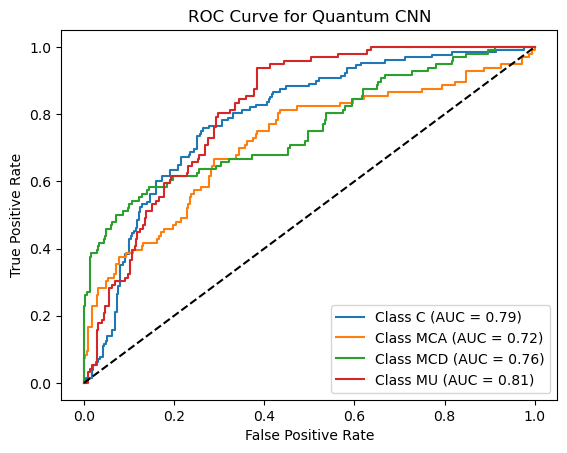

In [27]:
q_predictions=q_model.predict(q_test_images)
auc_scores = []
for i in range(test_labels.shape[1]):
    auc = roc_auc_score(test_labels[:, i], q_predictions[:, i])
    auc_scores.append(auc)
    print(f"AUC for class {i+1}:", auc)

# Promedio del AUC:
mean_auc = np.mean(auc_scores)
print("Mean AUC:", mean_auc)

# F1_Score y Accuracy (calculado como promedio micro):
f1 = f1_score(test_labels, np.round(q_predictions), average='micro')
print('F1_Score:', f1)

# Accuracy:
acc = accuracy_score(test_labels, np.round(q_predictions))
print('ACC:', acc)

# Si quieres también obtener las curvas ROC para cada clase:
fpr = dict()
tpr = dict()
thresholds = dict()

for i in range(test_labels.shape[1]):
    fpr[i], tpr[i], thresholds[i] = roc_curve(test_labels[:, i], q_predictions[:, i])

for i in range(test_labels.shape[1]):
    plt.plot(fpr[i], tpr[i], label=f'Class {Encoder.categories_[0][i]} (AUC = {auc_scores[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Quantum CNN')
plt.legend(loc='best')
plt.show()

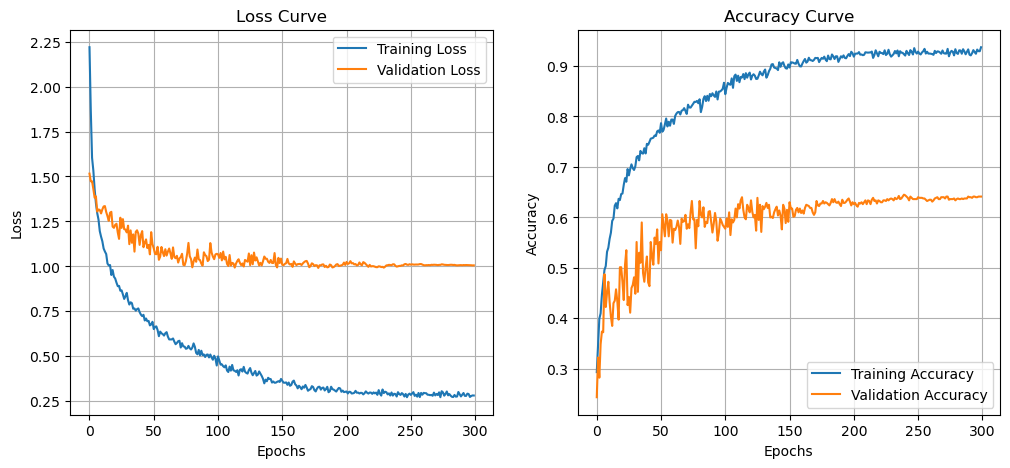

In [28]:
history = q_history.history

# Plot Loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()
plt.grid()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()
plt.grid()

plt.show()

## CNN

In [33]:
c_model = cnn(input_size=[64,64],learning_rate = 0.001, activation = 'relu', dropout = 0.5, num_classes=4)
lr_callback = ReduceLROnPlateau(monitor='val_loss', factor=0.6, patience=20, verbose=1)

c_model.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv3d_3 (Conv3D)           (None, 63, 63, 1, 24)     312       
                                                                 
 reshape_3 (Reshape)         (None, 63, 63, 24)        0         
                                                                 
 conv2d_18 (Conv2D)          (None, 63, 63, 64)        13888     
                                                                 
 batch_normalization_18 (Bat  (None, 63, 63, 64)       256       
 chNormalization)                                                
                                                                 
 dropout_18 (Dropout)        (None, 63, 63, 64)        0         
                                                                 
 max_pooling2d_12 (MaxPoolin  (None, 21, 21, 64)       0         
 g2D)                                                 

In [34]:
c_history = c_model.fit(
    train_imgs_tf,
    train_labels,
    validation_data=(val_imgs_tf, val_labels),
    batch_size=512,
    epochs=300,
    verbose=2,
    callbacks=[lr_callback]
)

Epoch 1/300
6/6 - 2s - loss: 2.4222 - accuracy: 0.2619 - val_loss: 1.5020 - val_accuracy: 0.2400 - lr: 0.0010 - 2s/epoch - 388ms/step
Epoch 2/300
6/6 - 1s - loss: 2.1073 - accuracy: 0.2978 - val_loss: 1.5627 - val_accuracy: 0.2062 - lr: 0.0010 - 951ms/epoch - 158ms/step
Epoch 3/300
6/6 - 1s - loss: 1.8980 - accuracy: 0.3193 - val_loss: 1.6254 - val_accuracy: 0.2000 - lr: 0.0010 - 949ms/epoch - 158ms/step
Epoch 4/300
6/6 - 1s - loss: 1.8096 - accuracy: 0.3545 - val_loss: 1.6944 - val_accuracy: 0.2000 - lr: 0.0010 - 953ms/epoch - 159ms/step
Epoch 5/300
6/6 - 1s - loss: 1.6591 - accuracy: 0.3919 - val_loss: 1.8856 - val_accuracy: 0.2000 - lr: 0.0010 - 948ms/epoch - 158ms/step
Epoch 6/300
6/6 - 1s - loss: 1.6137 - accuracy: 0.4055 - val_loss: 2.1328 - val_accuracy: 0.2000 - lr: 0.0010 - 953ms/epoch - 159ms/step
Epoch 7/300
6/6 - 1s - loss: 1.5558 - accuracy: 0.4210 - val_loss: 2.2697 - val_accuracy: 0.2000 - lr: 0.0010 - 952ms/epoch - 159ms/step
Epoch 8/300
6/6 - 1s - loss: 1.4868 - accura

13/13 [==============================] - 0s 3ms/step
AUC for class 1: 0.740451388888889
AUC for class 2: 0.7426757812499999
AUC for class 3: 0.7520833333333333
AUC for class 4: 0.7509440104166666
Mean AUC: 0.7465386284722222
F1_Score: 0.39938556067588327
ACC: 0.3125


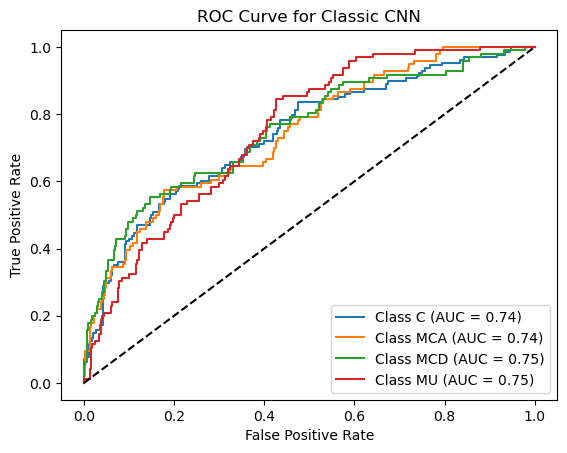

In [35]:
c_predictions=c_model.predict(test_imgs_tf)
auc_scores = []
for i in range(test_labels.shape[1]):
    auc = roc_auc_score(test_labels[:, i], c_predictions[:, i])
    auc_scores.append(auc)
    print(f"AUC for class {i+1}:", auc)

# Promedio del AUC:
mean_auc = np.mean(auc_scores)
print("Mean AUC:", mean_auc)

# F1_Score y Accuracy (calculado como promedio micro):
f1 = f1_score(test_labels, np.round(c_predictions), average='micro')
print('F1_Score:', f1)

# Accuracy:
acc = accuracy_score(test_labels, np.round(c_predictions))
print('ACC:', acc)

# Si quieres también obtener las curvas ROC para cada clase:
fpr = dict()
tpr = dict()
thresholds = dict()

for i in range(test_labels.shape[1]):
    fpr[i], tpr[i], thresholds[i] = roc_curve(test_labels[:, i], c_predictions[:, i])

for i in range(test_labels.shape[1]):
    plt.plot(fpr[i], tpr[i], label=f'Class {Encoder.categories_[0][i]} (AUC = {auc_scores[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Classic CNN')
plt.legend(loc='best')
plt.show()

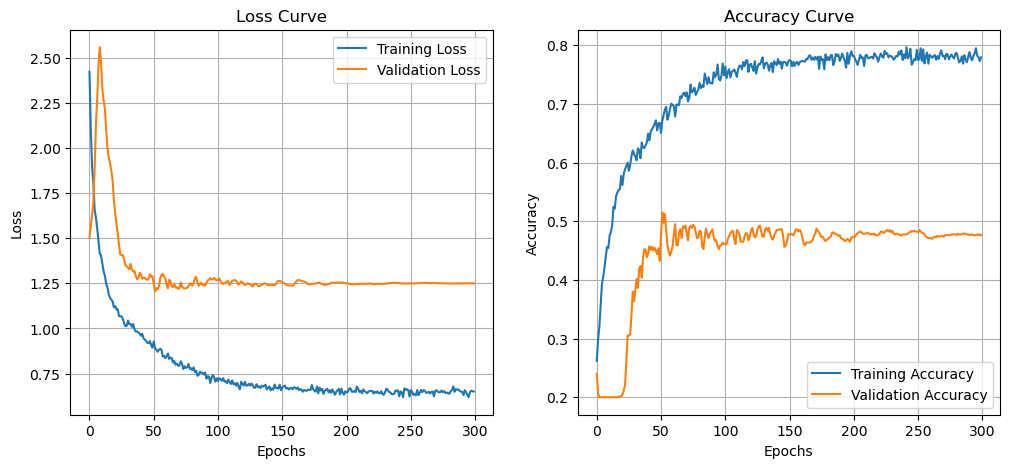

In [36]:
history = c_history.history

# Plot Loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()
plt.grid()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()
plt.grid()

plt.show()

# Robustez de los resultados

In [11]:
num_modelos= 10
classic_accuracies=[]
quantum_accuracies=[]

In [12]:
epochs=250

In [15]:
for _ in range(num_modelos):
    c_model  = cnn(input_size=[64,64],learning_rate = 0.001, activation = 'relu', dropout = 0.5, num_classes=4)
    lr_callback = ReduceLROnPlateau(monitor='val_loss', factor=0.6, patience=20, verbose=1)
    
    c_history = c_model.fit(
        train_imgs_tf,
        train_labels,
        validation_data=(val_imgs_tf, val_labels),
        batch_size=512,
        epochs=300,
        verbose=0,
        callbacks=[lr_callback]
    )

    classic_accuracies.append(c_history.history['val_accuracy'])


Epoch 136: ReduceLROnPlateau reducing learning rate to 0.0006000000284984708.

Epoch 156: ReduceLROnPlateau reducing learning rate to 0.0003600000170990825.

Epoch 176: ReduceLROnPlateau reducing learning rate to 0.00021600000327453016.

Epoch 196: ReduceLROnPlateau reducing learning rate to 0.00012960000021848827.

Epoch 216: ReduceLROnPlateau reducing learning rate to 7.775999838486313e-05.

Epoch 236: ReduceLROnPlateau reducing learning rate to 4.6655999904032795e-05.

Epoch 256: ReduceLROnPlateau reducing learning rate to 2.799360081553459e-05.

Epoch 276: ReduceLROnPlateau reducing learning rate to 1.6796160707599483e-05.

Epoch 296: ReduceLROnPlateau reducing learning rate to 1.007769642455969e-05.

Epoch 21: ReduceLROnPlateau reducing learning rate to 0.0006000000284984708.

Epoch 84: ReduceLROnPlateau reducing learning rate to 0.0003600000170990825.

Epoch 104: ReduceLROnPlateau reducing learning rate to 0.00021600000327453016.

Epoch 126: ReduceLROnPlateau reducing learning r

In [ ]:
for _ in range(num_modelos):
    q_model  = qcnn(input_size=[64,64], learning_rate = 0.001, activation = 'relu', dropout = 0.5, num_classes=4)
    lr_callback = ReduceLROnPlateau(monitor='val_loss', factor=0.6, patience=20, verbose=1)
    
    q_history = q_model.fit(
        q_train_images,
        train_labels,
        validation_data=(q_val_images, val_labels),
        batch_size=256,
        epochs=300,
        verbose=0,
        callbacks=[lr_callback]
    )

    quantum_accuracies.append(q_history.history['val_accuracy'])


Epoch 140: ReduceLROnPlateau reducing learning rate to 0.0006000000284984708.

Epoch 171: ReduceLROnPlateau reducing learning rate to 0.0003600000170990825.

Epoch 191: ReduceLROnPlateau reducing learning rate to 0.00021600000327453016.

Epoch 211: ReduceLROnPlateau reducing learning rate to 0.00012960000021848827.

Epoch 235: ReduceLROnPlateau reducing learning rate to 7.775999838486313e-05.

Epoch 270: ReduceLROnPlateau reducing learning rate to 4.6655999904032795e-05.

Epoch 290: ReduceLROnPlateau reducing learning rate to 2.799360081553459e-05.

Epoch 145: ReduceLROnPlateau reducing learning rate to 0.0006000000284984708.

Epoch 205: ReduceLROnPlateau reducing learning rate to 0.0003600000170990825.

Epoch 225: ReduceLROnPlateau reducing learning rate to 0.00021600000327453016.

Epoch 245: ReduceLROnPlateau reducing learning rate to 0.00012960000021848827.

Epoch 265: ReduceLROnPlateau reducing learning rate to 7.775999838486313e-05.

Epoch 285: ReduceLROnPlateau reducing learning

ResourceExhaustedError: Graph execution error:

Detected at node 'gradient_tape/sequential_23/batch_normalization_69/FusedBatchNormGradV3' defined at (most recent call last):
    File "c:\Users\mateo\anaconda3\envs\tensor_gpu\lib\runpy.py", line 197, in _run_module_as_main
      return _run_code(code, main_globals, None,
    File "c:\Users\mateo\anaconda3\envs\tensor_gpu\lib\runpy.py", line 87, in _run_code
      exec(code, run_globals)
    File "c:\Users\mateo\anaconda3\envs\tensor_gpu\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
      app.launch_new_instance()
    File "c:\Users\mateo\anaconda3\envs\tensor_gpu\lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
      app.start()
    File "c:\Users\mateo\anaconda3\envs\tensor_gpu\lib\site-packages\ipykernel\kernelapp.py", line 739, in start
      self.io_loop.start()
    File "c:\Users\mateo\anaconda3\envs\tensor_gpu\lib\site-packages\tornado\platform\asyncio.py", line 215, in start
    

In [ ]:
# Convert lists to numpy arrays for easier manipulation
q_accs = np.array(quantum_accuracies)
c_accs = np.array(classic_accuracies)

q_accs.shape
c_accs.shape 

(30, 400)

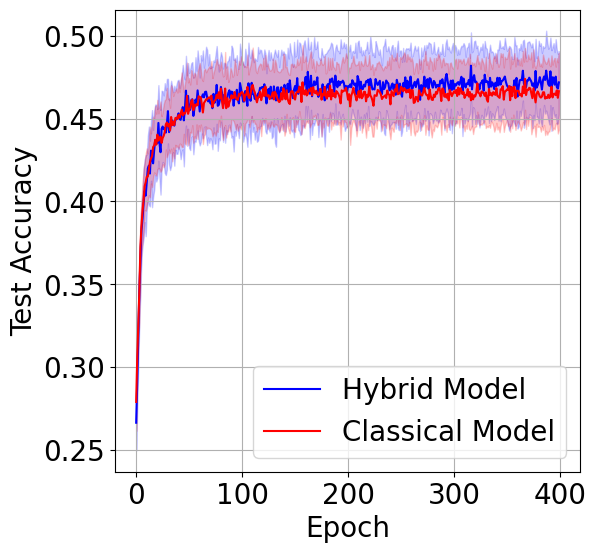

In [ ]:
plt.rcParams.update({'font.size': 20})

# Calculate mean and standard deviation
q_mean = np.mean(q_accs, axis=0)
q_std = np.std(q_accs, axis=0)
c_mean = np.mean(c_accs, axis=0)
c_std = np.std(c_accs, axis=0)

# Plot the results
epochs = np.arange(400)
plt.figure(figsize=(6, 6))

# Quantum model plot
plt.plot(epochs, q_mean, label='Hybrid Model', color='blue')
plt.fill_between(epochs, q_mean - q_std, q_mean + q_std, color='blue', alpha=0.2)

# Classical model plot
plt.plot(epochs, c_mean, label='Classical Model', color='red')
plt.fill_between(epochs, c_mean - c_std, c_mean + c_std, color='red', alpha=0.2)

plt.xlabel('Epoch')
plt.ylabel('Test Accuracy')
plt.legend()
plt.grid(True)
plt.show()